In [ ]:
# ============================================
# PROYECTO: Monitor de Eficiencia Municipal
# Autor: José Miguel Ríos Mallasca
# Fecha: 2026
# Notebook 01: Carga y Limpieza de Datos MEF
# ============================================

# --- LIBRERÍAS ---
from google.colab import drive
import pandas as pd
from bs4 import BeautifulSoup
import os

# --- CONECTAR DRIVE ---
drive.mount('/content/drive')

# --- LEER ARCHIVOS ---
ruta = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /01_Datos_Crudos  /'

años = [2023, 2024, 2025, 2026]
dataframes = []

for año in años:
    archivo = ruta + f'Lima_{año}.xls'
    print(f"⬇️ Leyendo {año}...")
    with open(archivo, 'r', encoding='latin-1') as f:
        contenido = f.read()
    soup = BeautifulSoup(contenido, 'html.parser')
    tabla = soup.find('table', {'class': 'Data'})
    filas = []
    for tr in tabla.find_all('tr'):
        celdas = [td.get_text(strip=True) for td in tr.find_all('td')]
        if len(celdas) >= 8:
            filas.append(celdas)
    df = pd.DataFrame(filas, columns=[
        'Municipalidad','PIA','PIM','Certificacion',
        'Compromiso_Anual','Atencion_Compromiso',
        'Devengado','Girado','Avance'
    ])
    df['año'] = año
    dataframes.append(df)
    print(f"  ✅ {año}: {len(df)} municipios")

# --- UNIR TODO ---
df_total = pd.concat(dataframes, ignore_index=True)
print(f"\n✅ TOTAL: {len(df_total)} filas cargadas")
print(df_total[['Municipalidad','PIM','Devengado','Avance','año']].head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⬇️ Leyendo 2023...
  ✅ 2023: 171 municipios
⬇️ Leyendo 2024...
  ✅ 2024: 171 municipios
⬇️ Leyendo 2025...
  ✅ 2025: 171 municipios
⬇️ Leyendo 2026...
  ✅ 2026: 171 municipios

✅ TOTAL: 684 filas cargadas
                                       Municipalidad         PIM   Devengado  \
0  150706-301344: MUNICIPALIDAD DISTRITAL  DE SAN...   2,444,223   2,374,463   
1     151002-301390: MUNICIPALIDAD DISTRITAL DE ALIS   5,635,180   5,233,396   
2    150802-301372: MUNICIPALIDAD DISTRITAL DE AMBAR   4,952,168   4,250,250   
3    150102-301251: MUNICIPALIDAD DISTRITAL DE ANCON  29,497,169  27,159,626   
4  150902-301384: MUNICIPALIDAD DISTRITAL DE ANDAJES   1,678,561   1,445,940   
5  150702-301340: MUNICIPALIDAD DISTRITAL DE ANTI...   4,770,271   4,257,167   
6  150402-301305: MUNICIPALIDAD DISTRITAL DE ARAHUAY  23,116,075   2,183,056   
7     150502-301312: MUNIC

In [ ]:
# ============================================
# CELDA 2: Limpieza de datos
# ============================================

# Limpiar nombre de municipio (quitar código del inicio)
df_total['Municipalidad'] = df_total['Municipalidad'].str.replace(
    r'^\d+[-]\d+:\s*', '', regex=True
).str.strip()

# Convertir columnas numéricas
for col in ['PIA','PIM','Certificacion','Compromiso_Anual',
            'Atencion_Compromiso','Devengado','Girado']:
    df_total[col] = pd.to_numeric(
        df_total[col].str.replace(',',''), errors='coerce'
    )

# Convertir Avance a número
df_total['Avance'] = pd.to_numeric(
    df_total['Avance'].str.replace('\xa0','').str.strip(),
    errors='coerce'
)

# Calcular % ejecución propio
df_total['pct_ejecucion'] = (df_total['Devengado'] / df_total['PIM'] * 100).round(1)

print("✅ Datos limpios")
print(f"Columnas: {list(df_total.columns)}")
print(df_total[['Municipalidad','PIM','Devengado','pct_ejecucion','año']].head(10))

✅ Datos limpios
Columnas: ['Municipalidad', 'PIA', 'PIM', 'Certificacion', 'Compromiso_Anual', 'Atencion_Compromiso', 'Devengado', 'Girado', 'Avance', 'año', 'pct_ejecucion']
                                       Municipalidad       PIM  Devengado  \
0  MUNICIPALIDAD DISTRITAL  DE SAN JOSE DE LOS CH...   2444223    2374463   
1                    MUNICIPALIDAD DISTRITAL DE ALIS   5635180    5233396   
2                   MUNICIPALIDAD DISTRITAL DE AMBAR   4952168    4250250   
3                   MUNICIPALIDAD DISTRITAL DE ANCON  29497169   27159626   
4                 MUNICIPALIDAD DISTRITAL DE ANDAJES   1678561    1445940   
5               MUNICIPALIDAD DISTRITAL DE ANTIOQUIA   4770271    4257167   
6                 MUNICIPALIDAD DISTRITAL DE ARAHUAY  23116075    2183056   
7                    MUNICIPALIDAD DISTRITAL DE ASIA  50007882   36697070   
8          MUNICIPALIDAD DISTRITAL DE ATAVILLOS ALTO   1859081    1493000   
9          MUNICIPALIDAD DISTRITAL DE ATAVILLOS BAJO   

In [ ]:
# ============================================
# CELDA 3: Guardar datos limpios + Primer análisis
# ============================================
import os

ruta_limpia = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /02_Datos_Limpios /'
df_total.to_csv(ruta_limpia + 'datos_limpios_2023_2026.csv', index=False)
print("✅ Archivo guardado en 02_Datos_Limpios")

# --- ANÁLISIS 1: Ranking 2023 ---
print("\n🏆 TOP 10 municipios más eficientes en 2023:")
top10 = (df_total[df_total['año']==2023]
         .sort_values('pct_ejecucion', ascending=False)
         [['Municipalidad','PIM','Devengado','pct_ejecucion']]
         .head(10))
print(top10.to_string(index=False))

# --- ANÁLISIS 2: Los peores ---
print("\n⚠️ TOP 10 municipios con MENOR ejecución en 2023:")
bottom10 = (df_total[df_total['año']==2023]
            .sort_values('pct_ejecucion', ascending=True)
            [['Municipalidad','PIM','Devengado','pct_ejecucion']]
            .head(10))
print(bottom10.to_string(index=False))

# --- ANÁLISIS 3: Promedio por año ---
print("\n📊 Promedio de ejecución por año:")
promedio = df_total.groupby('año')['pct_ejecucion'].mean().round(1)
print(promedio)

✅ Archivo guardado en 02_Datos_Limpios

🏆 TOP 10 municipios más eficientes en 2023:
                                                  Municipalidad     PIM  Devengado  pct_ejecucion
               MUNICIPALIDAD DISTRITAL DE SAN LORENZO DE QUINTI 2985973    2944969           98.6
                               MUNICIPALIDAD DISTRITAL DE SURCO 4871636    4776424           98.0
MUNICIPALIDAD DISTRITAL  DE SAN JOSE DE LOS CHORRILLOS - CUENCA 2444223    2374463           97.1
                              MUNICIPALIDAD DISTRITAL DE PACCHO 2755661    2673409           97.0
                         MUNICIPALIDAD DISTRITAL DE LAHUAYTAMBO 3082049    2983372           96.8
                               MUNICIPALIDAD DISTRITAL DE TANTA 1871625    1810664           96.7
            MUNICIPALIDAD DISTRITAL DE SANTA CRUZ DE COCACHACRA 4284871    4138623           96.6
                               MUNICIPALIDAD DISTRITAL DE MANAS 2515812    2411849           95.9
                            MUNICI

✅ Gráfico definitivo guardado


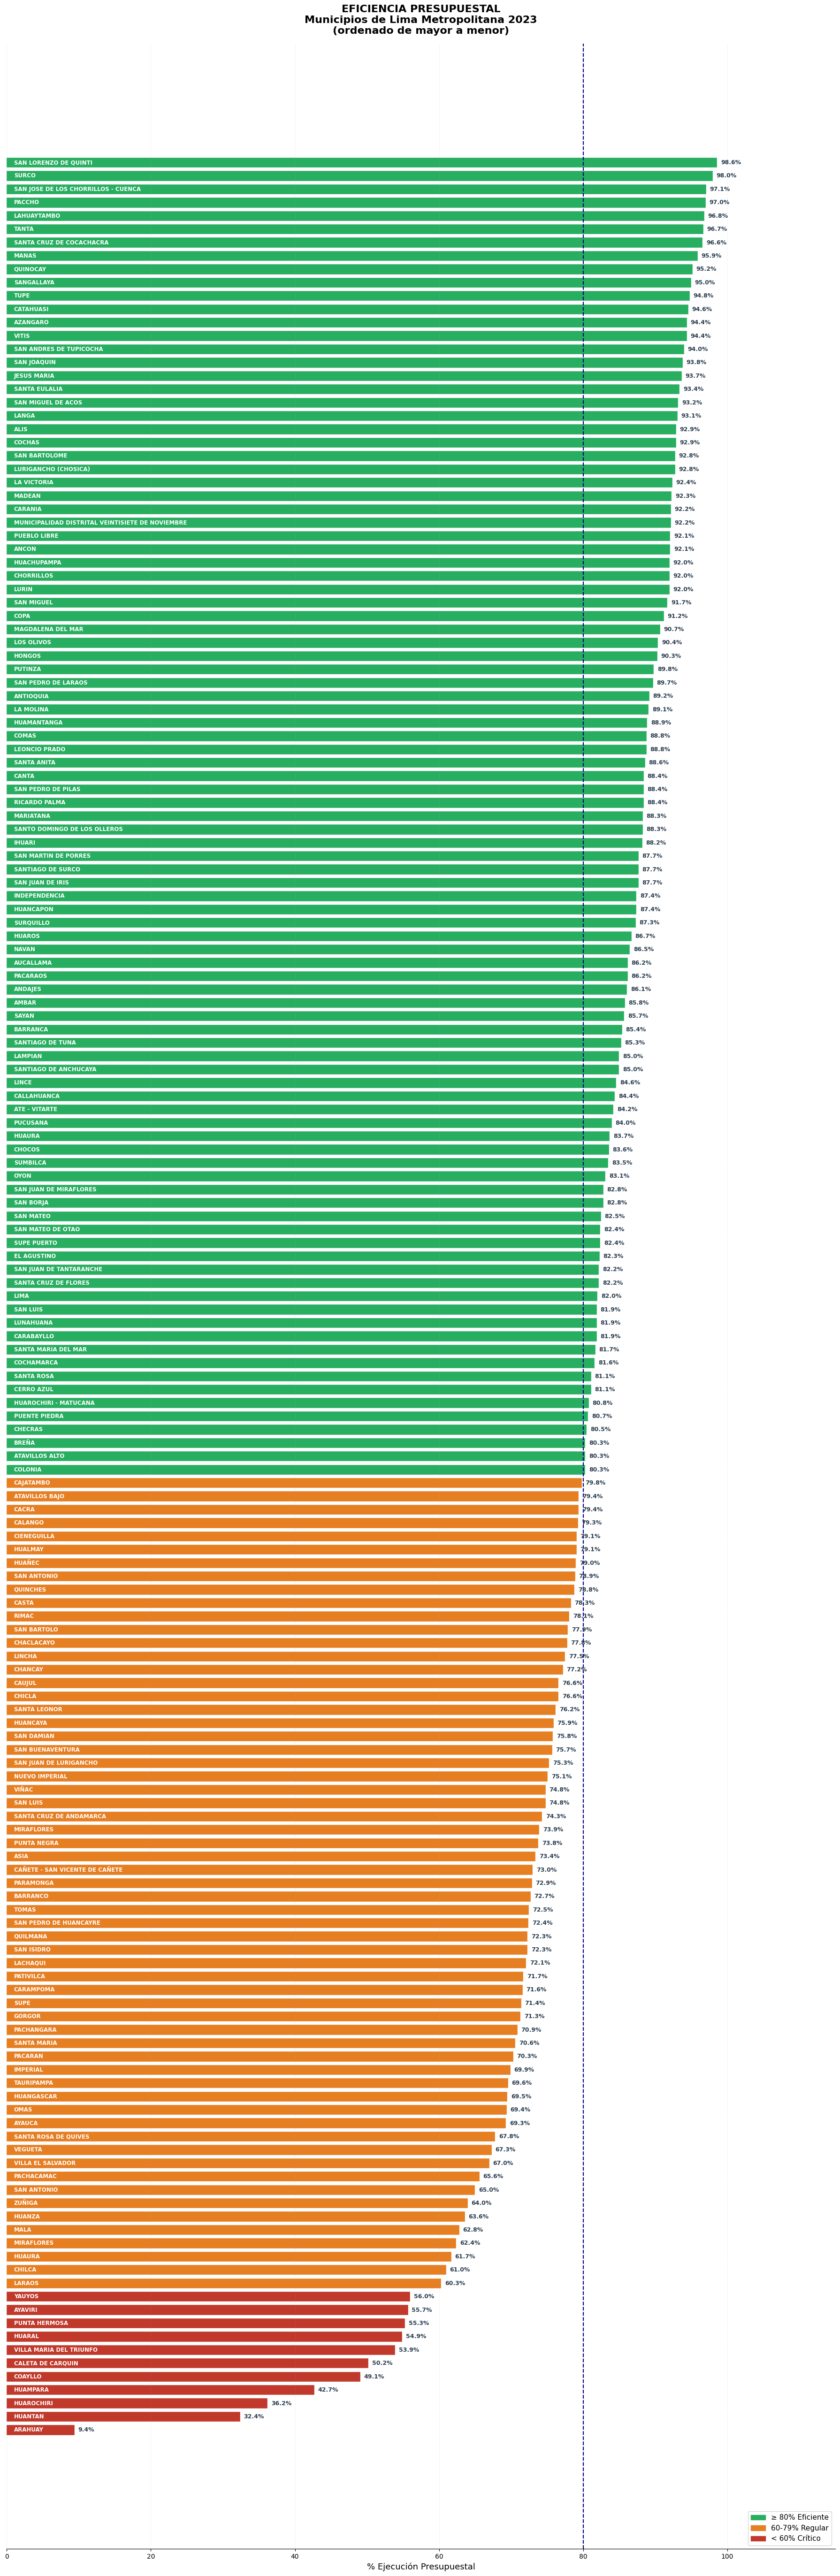

In [ ]:
# ============================================
# CELDA 4: Gráfico ranking 2023 (Fig01)
# ============================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_2023 = (df_total[df_total['año']==2023]
           .sort_values('pct_ejecucion', ascending=True)
           .copy())

df_2023['nombre_corto'] = (df_2023['Municipalidad']
    .str.replace('MUNICIPALIDAD DISTRITAL DE ','', regex=False)
    .str.replace('MUNICIPALIDAD PROVINCIAL DE ','', regex=False)
    .str.replace('MUNICIPALIDAD METROPOLITANA DE ','', regex=False)
    .str.replace('MUNICIPALIDAD DISTRITAL  DE ','', regex=False)
    .str.strip())

def color(x):
    if x >= 80: return '#27ae60'
    elif x >= 60: return '#e67e22'
    else: return '#c0392b'

colores = df_2023['pct_ejecucion'].apply(color)

fig, ax = plt.subplots(figsize=(18, 55))

ax.barh(range(len(df_2023)),
        df_2023['pct_ejecucion'],
        color=colores, height=0.75,
        edgecolor='white', linewidth=0.3)

ax.axvline(x=80, color='navy', linestyle='--', linewidth=1.5)

# Nombre DENTRO de la barra + % afuera
for i, (val, nombre) in enumerate(zip(df_2023['pct_ejecucion'], df_2023['nombre_corto'])):
    # Nombre dentro de la barra
    ax.text(1, i, nombre,
            va='center', ha='left',
            fontsize=8.5, color='white', fontweight='bold')
    # % fuera de la barra
    ax.text(val + 0.5, i, f'{val}%',
            va='center', ha='left',
            fontsize=9, color='#2c3e50', fontweight='bold')

ax.set_yticks([])  # quitar etiquetas eje Y
ax.set_xlabel('% Ejecución Presupuestal', fontsize=13)
ax.set_xlim(0, 115)
ax.set_title('EFICIENCIA PRESUPUESTAL\nMunicipios de Lima Metropolitana 2023\n(ordenado de mayor a menor)',
             fontsize=16, fontweight='bold', pad=15)

verde = mpatches.Patch(color='#27ae60', label='≥ 80% Eficiente')
naranja = mpatches.Patch(color='#e67e22', label='60-79% Regular')
rojo = mpatches.Patch(color='#c0392b', label='< 60% Crítico')
ax.legend(handles=[verde, naranja, rojo], loc='lower right', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle=':')

plt.tight_layout()

ruta_out = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /05_Reportes   /'
plt.savefig(ruta_out + 'ranking_2023_DEFINITIVO.png', dpi=200, bbox_inches='tight')
print("✅ Gráfico definitivo guardado")
plt.show()

✅ Fig02 guardado


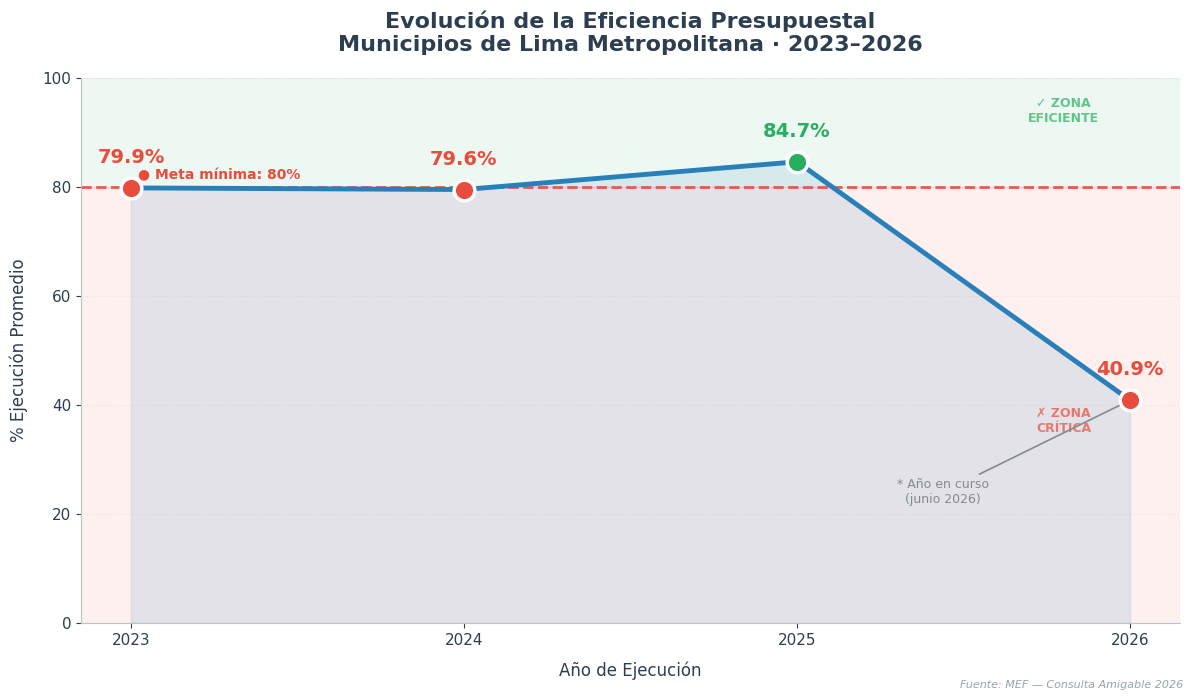

In [ ]:
# ============================================
# CELDA 5: Evolución 2023-2026 (Fig02)
# ============================================
import matplotlib.pyplot as plt

evolucion = df_total.groupby('año')['pct_ejecucion'].mean().round(1)
años = list(evolucion.index)
valores = list(evolucion.values)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Zona ROJA — bajo la meta
ax.axhspan(0, 80, alpha=0.08, color='#e74c3c', label='Bajo meta')

# Zona VERDE — sobre la meta
ax.axhspan(80, 100, alpha=0.08, color='#27ae60', label='Sobre meta')

# Línea meta
ax.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.9, zorder=2)
ax.text(2023.02, 81.5, '● Meta mínima: 80%', color='#e74c3c', fontsize=10, fontweight='bold')

# Etiquetas de zona
ax.text(2025.8, 92, '✓ ZONA\nEFICIENTE', color='#27ae60', fontsize=9,
        fontweight='bold', alpha=0.7, ha='center')
ax.text(2025.8, 35, '✗ ZONA\nCRÍTICA', color='#e74c3c', fontsize=9,
        fontweight='bold', alpha=0.7, ha='center')

# Área bajo la curva
ax.fill_between(años, valores, alpha=0.12, color='#2980b9')

# Línea principal
ax.plot(años, valores, color='#2980b9', linewidth=3.5, zorder=3)

# Puntos coloreados por zona
for año, val in zip(años, valores):
    color_punto = '#27ae60' if val >= 80 else '#e74c3c'
    ax.scatter(año, val, s=220, color=color_punto,
               zorder=5, edgecolors='white', linewidth=2.5)
    color_label = '#27ae60' if val >= 80 else '#e74c3c'
    ax.annotate(f'{val}%',
                xy=(año, val),
                xytext=(0, 18),
                textcoords='offset points',
                ha='center', fontsize=14, fontweight='bold',
                color=color_label)

# Nota 2026
ax.annotate('* Año en curso\n  (junio 2026)',
            xy=(2026, 40.9),
            xytext=(2025.3, 22),
            fontsize=9, color='#7f8c8d',
            arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.2))

# Estilo
ax.set_xlabel('Año de Ejecución', fontsize=12, color='#2c3e50', labelpad=10)
ax.set_ylabel('% Ejecución Promedio', fontsize=12, color='#2c3e50', labelpad=10)
ax.set_title('Evolución de la Eficiencia Presupuestal\nMunicipios de Lima Metropolitana · 2023–2026',
             fontsize=16, fontweight='bold', color='#2c3e50', pad=20)
ax.set_ylim(0, 100)
ax.set_xticks([2023, 2024, 2025, 2026])
ax.tick_params(labelsize=11, colors='#2c3e50')
ax.grid(axis='y', alpha=0.3, linestyle=':', color='#bdc3c7')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

fig.text(0.99, 0.01, 'Fuente: MEF — Consulta Amigable 2026',
         ha='right', fontsize=8, color='#95a5a6', style='italic')

plt.tight_layout()

ruta_out = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /05_Reportes   /'
plt.savefig(ruta_out + 'Fig02_Evolucion_2023_2026.png',
            dpi=200, bbox_inches='tight', facecolor='white')
print("✅ Fig02 guardado")
plt.show()

In [ ]:
# CELDA 6: Instalar librerías para el mapa
!pip install geopandas folium mapclassify -q
print("Listo ✅")

Listo ✅


In [ ]:
# CELDA 7: Descomprimir shapefile y cargar
import zipfile
import os
import geopandas as gpd

ruta_zip = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /01_Datos_Crudos  /DISTRITOS_LIMITES.zip'
ruta_extraida = '/content/distritos_shp/'

# Descomprimir
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(ruta_extraida)

# Ver qué archivos hay adentro
print("Archivos extraídos:")
for archivo in os.listdir(ruta_extraida):
    print(' -', archivo)

Archivos extraídos:
 - DISTRITOS.dbf
 - DISTRITOS.shx
 - DISTRITOS.sbx
 - DISTRITOS.shp
 - DISTRITOS.shp.xml
 - DISTRITOS.sbn
 - DISTRITOS.CPG
 - DISTRITOS.prj


In [ ]:
# CELDA 8: Cargar shapefile y revisar
gdf_distritos = gpd.read_file('/content/distritos_shp/DISTRITOS.shp')

print("Número de distritos:", len(gdf_distritos))
print("\nColumnas disponibles:")
print(gdf_distritos.columns.tolist())
print("\nPrimeras filas:")
gdf_distritos.head()

Número de distritos: 1891

Columnas disponibles:
['OBJECTID_1', 'UBIGEO', 'CODDEP', 'DEPARTAMEN', 'CODPROV', 'PROVINCIA', 'CODDIST', 'DISTRITO', 'CAPITAL', 'FUENTE', 'geometry']

Primeras filas:


,OBJECTID_1,UBIGEO,CODDEP,DEPARTAMEN,CODPROV,PROVINCIA,CODDIST,DISTRITO,CAPITAL,FUENTE,geometry
0,1,030220,03,APURIMAC,02,ANDAHUAYLAS,20,JOSE MARIA ARGUEDAS,HUANCABAMBA,INEI,"POLYGON ((-73.37071 -13.70846, -73.36971 -13.7..."
1,2,030415,03,APURIMAC,04,AYMARAES,15,TINTAY,TINTAY,INEI,"POLYGON ((-73.17529 -13.80103, -73.17388 -13.8..."
2,3,030409,03,APURIMAC,04,AYMARAES,09,LUCRE,LUCRE,INEI,"POLYGON ((-73.24364 -13.81554, -73.24288 -13.8..."
3,4,030214,03,APURIMAC,02,ANDAHUAYLAS,14,SAN MIGUEL DE CHACCRAMPA,CHACCRAMPA,INEI,"POLYGON ((-73.63057 -13.90924, -73.62949 -13.9..."
4,5,030206,03,APURIMAC,02,ANDAHUAYLAS,06,HUAYANA,HUAYANA,INEI,"POLYGON ((-73.51096 -13.91122, -73.51029 -13.9..."


In [ ]:
# CELDA 9: Filtrar solo Lima Metropolitana
gdf_lima = gdf_distritos[
    (gdf_distritos['DEPARTAMEN'] == 'LIMA') &
    (gdf_distritos['PROVINCIA'] == 'LIMA')
].copy()

print("Distritos de Lima Metropolitana encontrados:", len(gdf_lima))
print("\nLista de distritos:")
print(sorted(gdf_lima['DISTRITO'].unique()))

Distritos de Lima Metropolitana encontrados: 43

Lista de distritos:
['ANCON', 'ATE', 'BARRANCO', 'BREÑA', 'CARABAYLLO', 'CHACLACAYO', 'CHORRILLOS', 'CIENEGUILLA', 'COMAS', 'EL AGUSTINO', 'INDEPENDENCIA', 'JESUS MARIA', 'LA MOLINA', 'LA VICTORIA', 'LIMA', 'LINCE', 'LOS OLIVOS', 'LURIGANCHO', 'LURIN', 'MAGDALENA DEL MAR', 'MIRAFLORES', 'PACHACAMAC', 'PUCUSANA', 'PUEBLO LIBRE', 'PUENTE PIEDRA', 'PUNTA HERMOSA', 'PUNTA NEGRA', 'RIMAC', 'SAN BARTOLO', 'SAN BORJA', 'SAN ISIDRO', 'SAN JUAN DE LURIGANCHO', 'SAN JUAN DE MIRAFLORES', 'SAN LUIS', 'SAN MARTIN DE PORRES', 'SAN MIGUEL', 'SANTA ANITA', 'SANTA MARIA DEL MAR', 'SANTA ROSA', 'SANTIAGO DE SURCO', 'SURQUILLO', 'VILLA EL SALVADOR', 'VILLA MARIA DEL TRIUNFO']


In [ ]:
# CELDA 10: Comparar nombres del shapefile vs nombres en df_total
nombres_shapefile = set(gdf_lima['DISTRITO'].str.upper().str.strip())
nombres_datos = set(df_total['Municipalidad'].str.upper().str.strip())

print("Distritos en el shapefile que NO aparecen igual en tus datos MEF:")
for nombre in sorted(nombres_shapefile - nombres_datos):
    print(' -', nombre)

print("\nNombres en tus datos MEF que NO aparecen igual en el shapefile:")
for nombre in sorted(nombres_datos - nombres_shapefile):
    print(' -', nombre)

Distritos en el shapefile que NO aparecen igual en tus datos MEF:
 - ANCON
 - ATE
 - BARRANCO
 - BREÑA
 - CARABAYLLO
 - CHACLACAYO
 - CHORRILLOS
 - CIENEGUILLA
 - COMAS
 - EL AGUSTINO
 - INDEPENDENCIA
 - JESUS MARIA
 - LA MOLINA
 - LA VICTORIA
 - LIMA
 - LINCE
 - LOS OLIVOS
 - LURIGANCHO
 - LURIN
 - MAGDALENA DEL MAR
 - MIRAFLORES
 - PACHACAMAC
 - PUCUSANA
 - PUEBLO LIBRE
 - PUENTE PIEDRA
 - PUNTA HERMOSA
 - PUNTA NEGRA
 - RIMAC
 - SAN BARTOLO
 - SAN BORJA
 - SAN ISIDRO
 - SAN JUAN DE LURIGANCHO
 - SAN JUAN DE MIRAFLORES
 - SAN LUIS
 - SAN MARTIN DE PORRES
 - SAN MIGUEL
 - SANTA ANITA
 - SANTA MARIA DEL MAR
 - SANTA ROSA
 - SANTIAGO DE SURCO
 - SURQUILLO
 - VILLA EL SALVADOR
 - VILLA MARIA DEL TRIUNFO

Nombres en tus datos MEF que NO aparecen igual en el shapefile:
 - MUNICIPALIDAD DISTRITAL  DE SAN JOSE DE LOS CHORRILLOS - CUENCA
 - MUNICIPALIDAD DISTRITAL DE ALIS
 - MUNICIPALIDAD DISTRITAL DE AMBAR
 - MUNICIPALIDAD DISTRITAL DE ANCON
 - MUNICIPALIDAD DISTRITAL DE ANDAJES
 - MUNICIPAL

In [ ]:
# CELDA 11: Crear columna de nombre limpio (sin prefijo) para cruzar con el mapa
df_total['distrito_limpio'] = (df_total['Municipalidad']
    .str.replace('MUNICIPALIDAD DISTRITAL DE ', '', regex=False)
    .str.replace('MUNICIPALIDAD PROVINCIAL DE ', '', regex=False)
    .str.replace('MUNICIPALIDAD METROPOLITANA DE ', '', regex=False)
    .str.replace('  DE ', ' DE ', regex=False)  # caso especial San José de los Chorrillos
    .str.strip()
    .str.upper())

# Volver a comparar contra el shapefile
nombres_shapefile = set(gdf_lima['DISTRITO'].str.upper().str.strip())
nombres_datos_limpios = set(df_total['distrito_limpio'])

print("Distritos del shapefile que TODAVÍA no coinciden:")
for nombre in sorted(nombres_shapefile - nombres_datos_limpios):
    print(' -', nombre)

Distritos del shapefile que TODAVÍA no coinciden:
 - ATE
 - LURIGANCHO


In [ ]:
# CELDA 12: Corregir los 2 casos especiales que no coinciden
correcciones = {
    'ATE - VITARTE': 'ATE',
    'LURIGANCHO (CHOSICA)': 'LURIGANCHO'
}

df_total['distrito_limpio'] = df_total['distrito_limpio'].replace(correcciones)

# Verificar de nuevo que ya no falte ninguno
nombres_shapefile = set(gdf_lima['DISTRITO'].str.upper().str.strip())
nombres_datos_limpios = set(df_total['distrito_limpio'])

faltantes = nombres_shapefile - nombres_datos_limpios
print("Distritos que aún no coinciden:", faltantes if faltantes else "¡Ninguno! ✅")

Distritos que aún no coinciden: ¡Ninguno! ✅


In [ ]:
# CELDA 13: Crear df_lima_metro — solo los 43 distritos de Lima Metropolitana
distritos_lima_metro = set(gdf_lima['DISTRITO'].str.upper().str.strip())

df_lima_metro = df_total[df_total['distrito_limpio'].isin(distritos_lima_metro)].copy()

print("Filas en df_total (171 municipios):", len(df_total))
print("Filas en df_lima_metro (43 distritos):", len(df_lima_metro))
print("\nDistritos únicos en df_lima_metro:", df_lima_metro['distrito_limpio'].nunique())
print("\n¿Son 43 × 4 años = 172 filas?", len(df_lima_metro) == 43*4)

Filas en df_total (171 municipios): 684
Filas en df_lima_metro (43 distritos): 180

Distritos únicos en df_lima_metro: 43

¿Son 43 × 4 años = 172 filas? False


In [ ]:
# CELDA 14: Detectar duplicados en df_lima_metro
conteo = df_lima_metro.groupby('distrito_limpio')['año'].count().sort_values(ascending=False)

print("Distritos con más de 4 filas (duplicados):")
print(conteo[conteo > 4])

Distritos con más de 4 filas (duplicados):
distrito_limpio
MIRAFLORES    8
SAN LUIS      8
Name: año, dtype: int64


In [ ]:
# CELDA 15: Investigar el duplicado de Miraflores y San Luis
revision = df_lima_metro[df_lima_metro['distrito_limpio'].isin(['MIRAFLORES', 'SAN LUIS'])]
revision[['Municipalidad', 'distrito_limpio', 'año', 'PIM', 'Devengado', 'pct_ejecucion']].sort_values(['distrito_limpio', 'año'])

,Municipalidad,distrito_limpio,año,PIM,Devengado,pct_ejecucion
81,MUNICIPALIDAD DISTRITAL DE MIRAFLORES,MIRAFLORES,2023,305639797,190680190,62.4
82,MUNICIPALIDAD DISTRITAL DE MIRAFLORES,MIRAFLORES,2023,1711913,1264604,73.9
192,MUNICIPALIDAD DISTRITAL DE MIRAFLORES,MIRAFLORES,2024,370719549,336707376,90.8
329,MUNICIPALIDAD DISTRITAL DE MIRAFLORES,MIRAFLORES,2024,1388219,1082699,78.0
363,MUNICIPALIDAD DISTRITAL DE MIRAFLORES,MIRAFLORES,2025,387456981,362575233,93.6
500,MUNICIPALIDAD DISTRITAL DE MIRAFLORES,MIRAFLORES,2025,2677463,2125274,79.4
534,MUNICIPALIDAD DISTRITAL DE MIRAFLORES,MIRAFLORES,2026,322956990,141884452,43.9
671,MUNICIPALIDAD DISTRITAL DE MIRAFLORES,MIRAFLORES,2026,1026764,386395,37.6
119,MUNICIPALIDAD DISTRITAL DE SAN LUIS,SAN LUIS,2023,36748736,30085304,81.9
120,MUNICIPALIDAD DISTRITAL DE SAN LUIS,SAN LUIS,2023,11940447,8930454,74.8


In [ ]:
# CELDA 16: Revisar si hay forma de diferenciar los Miraflores/San Luis duplicados
# Vemos las filas completas, todas las columnas, para detectar alguna pista (orden de aparición, etc.)
pd.set_option('display.max_columns', None)
revision_completa = df_total[df_total['Municipalidad'].isin([
    'MUNICIPALIDAD DISTRITAL DE MIRAFLORES',
    'MUNICIPALIDAD DISTRITAL DE SAN LUIS'
]) & (df_total['año']==2023)]
revision_completa

,Municipalidad,PIA,PIM,Certificacion,Compromiso_Anual,Atencion_Compromiso,Devengado,Girado,Avance,año,pct_ejecucion,distrito_limpio
81,MUNICIPALIDAD DISTRITAL DE MIRAFLORES,238936449,305639797,242536459,190911710,190911710,190680190,190632376,62.4,2023,62.4,MIRAFLORES
82,MUNICIPALIDAD DISTRITAL DE MIRAFLORES,590919,1711913,1413324,1283790,1282910,1264604,1260334,73.9,2023,73.9,MIRAFLORES
119,MUNICIPALIDAD DISTRITAL DE SAN LUIS,31516896,36748736,35638212,35012012,34796038,30085304,30032330,81.9,2023,81.9,SAN LUIS
120,MUNICIPALIDAD DISTRITAL DE SAN LUIS,6804645,11940447,9648746,9178718,9174035,8930454,8924685,74.8,2023,74.8,SAN LUIS


In [ ]:
# CELDA 17: Confirmar ubigeo real de Miraflores y San Luis en Lima Metropolitana
ubigeo_lima = gdf_lima[gdf_lima['DISTRITO'].isin(['MIRAFLORES', 'SAN LUIS'])][['DISTRITO', 'UBIGEO']]
print(ubigeo_lima)

       DISTRITO  UBIGEO
970  MIRAFLORES  150122
974    SAN LUIS  150134


In [ ]:
# CELDA 18: Revisar si el archivo crudo original tenía el ubigeo antes de limpiarlo
# (esto solo aplica si guardaste el dataframe crudo sin limpiar — si no lo tienes, lo omitimos)
print('Municipalidad' in df_total.columns)
print(df_total[df_total['Municipalidad'].str.contains('MIRAFLORES', na=False)]['Municipalidad'].unique())

True
['MUNICIPALIDAD DISTRITAL DE MIRAFLORES'
 'MUNICIPALIDAD DISTRITAL DE SAN JUAN DE MIRAFLORES']


In [ ]:
# CELDA 19: Eliminar los homónimos (quedarse con el PIM más alto por año)
df_lima_metro_limpio = (df_lima_metro
    .sort_values('PIM', ascending=False)
    .drop_duplicates(subset=['distrito_limpio', 'año'], keep='first')
    .copy())

print("Filas finales:", len(df_lima_metro_limpio))
print("¿Son 43 × 4 = 172?", len(df_lima_metro_limpio) == 43*4)
print("\nVerificar Miraflores y San Luis quedaron bien:")
print(df_lima_metro_limpio[df_lima_metro_limpio['distrito_limpio'].isin(['MIRAFLORES','SAN LUIS'])]
      [['distrito_limpio','año','PIM','pct_ejecucion']].sort_values(['distrito_limpio','año']))

Filas finales: 172
¿Son 43 × 4 = 172? True

Verificar Miraflores y San Luis quedaron bien:
    distrito_limpio   año        PIM  pct_ejecucion
81       MIRAFLORES  2023  305639797           62.4
192      MIRAFLORES  2024  370719549           90.8
363      MIRAFLORES  2025  387456981           93.6
534      MIRAFLORES  2026  322956990           43.9
119        SAN LUIS  2023   36748736           81.9
204        SAN LUIS  2024   34390032           87.5
375        SAN LUIS  2025   45286979           94.1
546        SAN LUIS  2026   38234946           51.0


✅ Fig01 regenerada y guardada (43 distritos)


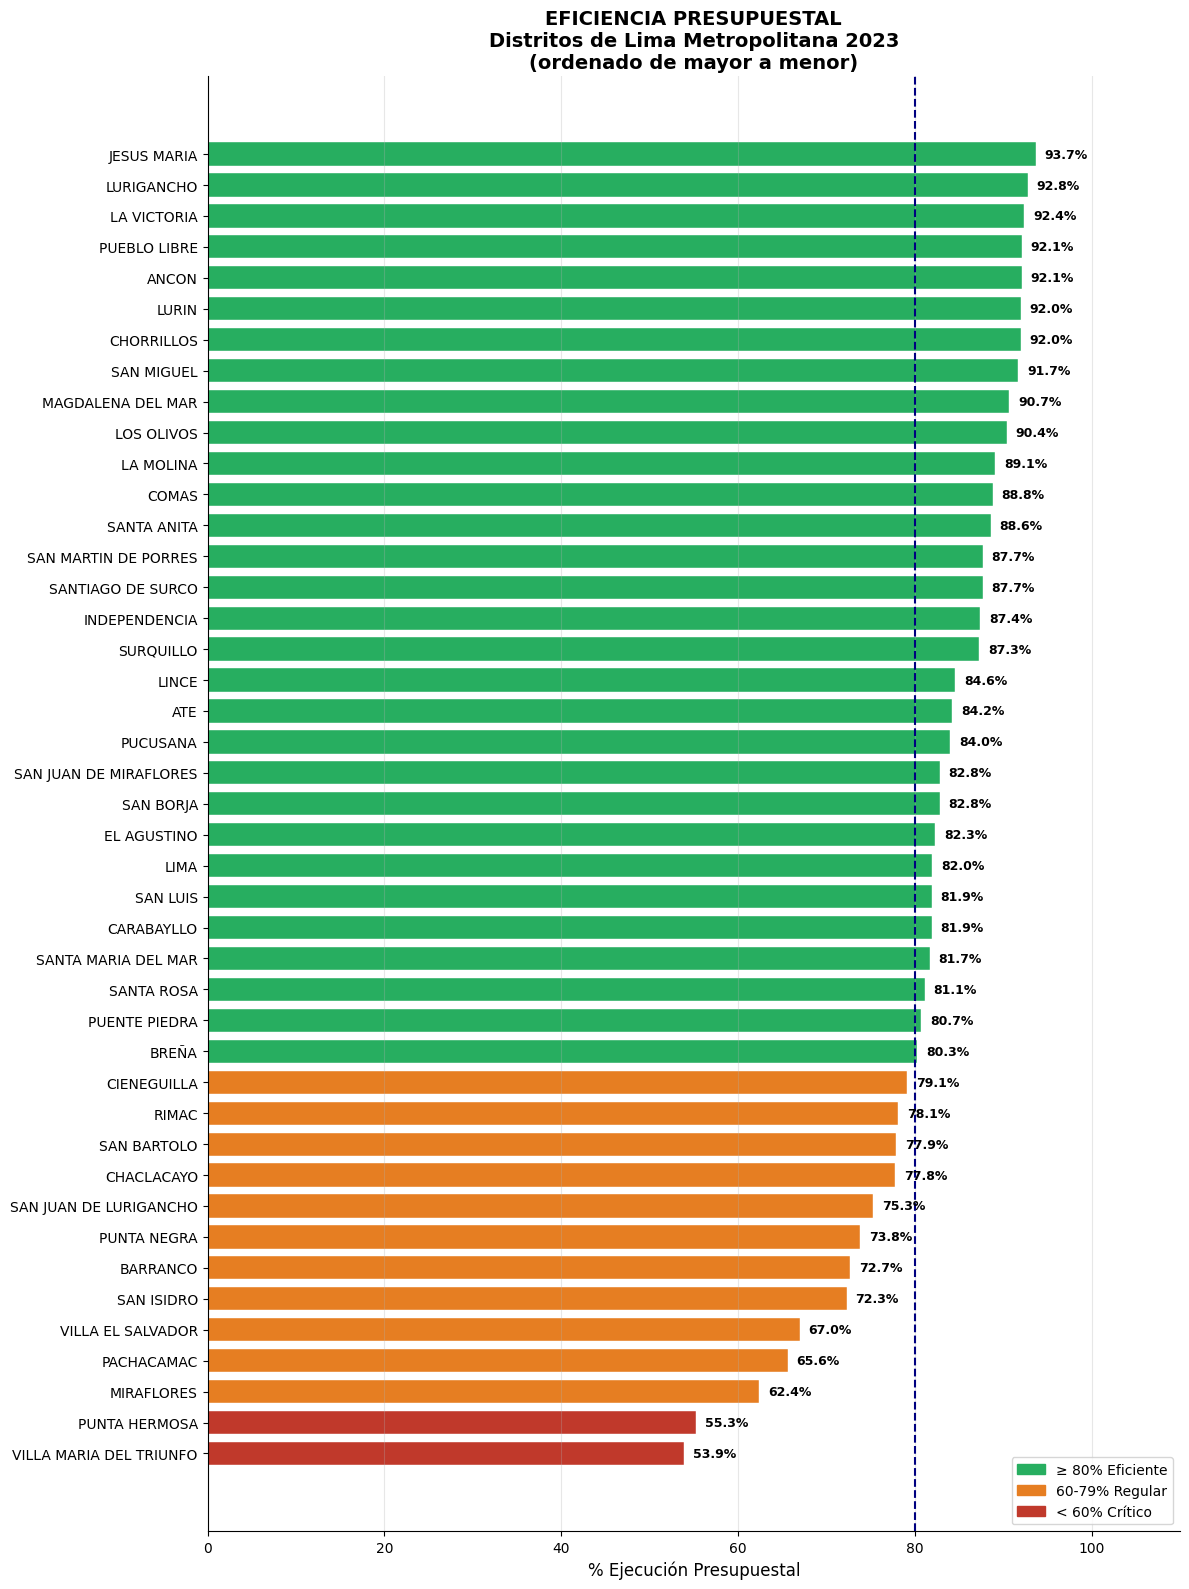

In [ ]:
# CELDA 20: Fig01 corregida — Ranking 2023, solo 43 distritos de Lima Metropolitana
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_2023 = (df_lima_metro_limpio[df_lima_metro_limpio['año']==2023]
           .sort_values('pct_ejecucion', ascending=True)
           .copy())

def color_por_pct(pct):
    if pct >= 80:
        return '#27ae60'
    elif pct >= 60:
        return '#e67e22'
    else:
        return '#c0392b'

colores = df_2023['pct_ejecucion'].apply(color_por_pct)

fig, ax = plt.subplots(figsize=(12, 16))

bars = ax.barh(df_2023['distrito_limpio'],
               df_2023['pct_ejecucion'],
               color=colores,
               height=0.75,
               edgecolor='white',
               linewidth=0.3)

ax.axvline(x=80, color='navy', linestyle='--', linewidth=1.5)

for i, val in enumerate(df_2023['pct_ejecucion']):
    ax.text(val + 1, i, f'{val}%', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('% Ejecución Presupuestal', fontsize=12)
ax.set_title('EFICIENCIA PRESUPUESTAL\nDistritos de Lima Metropolitana 2023\n(ordenado de mayor a menor)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

leyenda = [
    mpatches.Patch(color='#27ae60', label='≥ 80% Eficiente'),
    mpatches.Patch(color='#e67e22', label='60-79% Regular'),
    mpatches.Patch(color='#c0392b', label='< 60% Crítico')
]
ax.legend(handles=leyenda, loc='lower right', fontsize=10)

plt.tight_layout()

ruta_out = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /05_Reportes   /'
plt.savefig(ruta_out + 'Fig01_Eficiencia_Presupuestal_Lima_2023.png', dpi=200, bbox_inches='tight')
print("✅ Fig01 regenerada y guardada (43 distritos)")
plt.show()

✅ Fig02 regenerada y guardada (43 distritos)


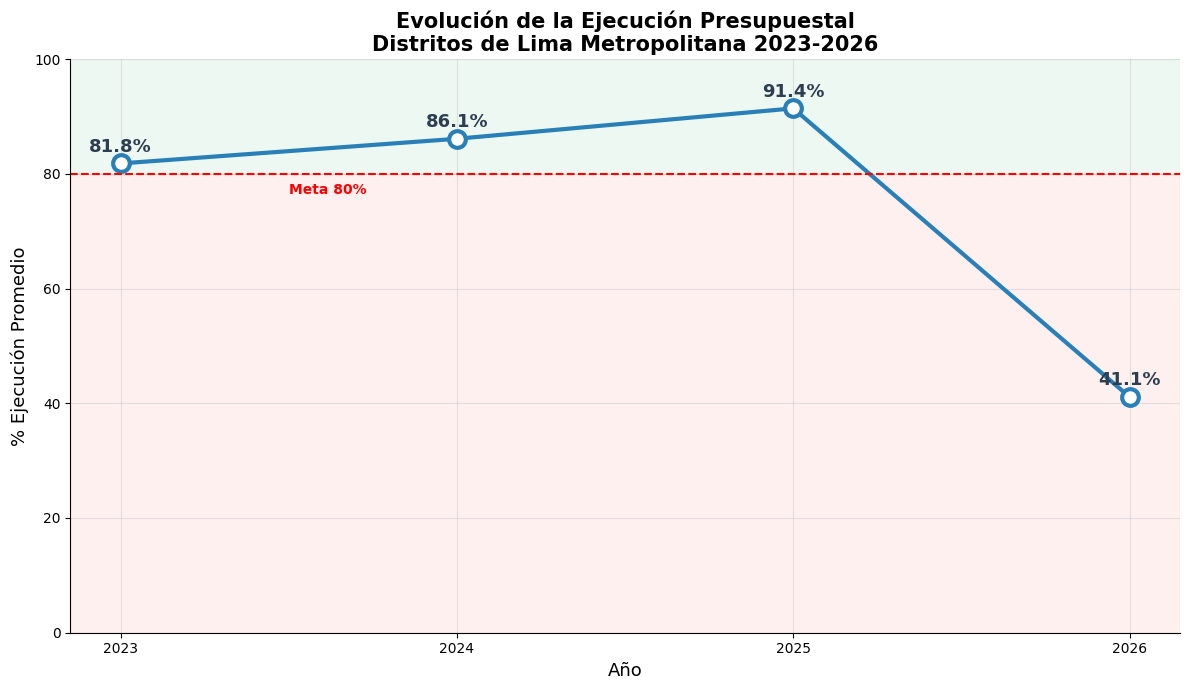

In [ ]:
# CELDA 21: Fig02 corregida — Evolución 2023-2026, solo 43 distritos de Lima Metropolitana
import matplotlib.pyplot as plt

evolucion = df_lima_metro_limpio.groupby('año')['pct_ejecucion'].mean().round(1)
años = list(evolucion.index)
valores = list(evolucion.values)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.axhspan(0, 80, alpha=0.08, color='#e74c3c')
ax.axhspan(80, 100, alpha=0.08, color='#27ae60')

ax.plot(años, valores,
        color='#2980b9', linewidth=3,
        marker='o', markersize=12, markerfacecolor='white',
        markeredgecolor='#2980b9', markeredgewidth=3)

for año, val in zip(años, valores):
    ax.text(año, val + 2, f'{val}%',
            ha='center', fontsize=13, fontweight='bold', color='#2c3e50')

ax.axhline(y=80, color='red', linestyle='--', linewidth=1.5)
ax.text(2023.5, 76.5, 'Meta 80%', color='red', fontsize=10, fontweight='bold')
ax.set_xlabel('Año', fontsize=13)
ax.set_ylabel('% Ejecución Promedio', fontsize=13)
ax.set_title('Evolución de la Ejecución Presupuestal\nDistritos de Lima Metropolitana 2023-2026',
             fontsize=15, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_xticks([2023, 2024, 2025, 2026])
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

ruta_out = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /05_Reportes   /'
plt.savefig(ruta_out + 'Fig02_Evolucion_2023_2026.png', dpi=200, bbox_inches='tight')
print("✅ Fig02 regenerada y guardada (43 distritos)")
plt.show()

In [ ]:
# CELDA 22: Cruzar shapefile con datos de ejecución (los 4 años)
gdf_lima_datos = gdf_lima.merge(
    df_lima_metro_limpio[['distrito_limpio', 'año', 'pct_ejecucion']],
    left_on='DISTRITO',
    right_on='distrito_limpio',
    how='left'
)

print("Filas resultantes:", len(gdf_lima_datos))
print("¿Son 43 distritos × 4 años = 172?", len(gdf_lima_datos) == 172)
print("\n¿Hay valores vacíos (NaN) en pct_ejecucion?")
print(gdf_lima_datos['pct_ejecucion'].isna().sum())

Filas resultantes: 172
¿Son 43 distritos × 4 años = 172? True

¿Hay valores vacíos (NaN) en pct_ejecucion?
0


✅ Fig03 guardada — Mapa de los 4 años (escala centrada en meta 80%)


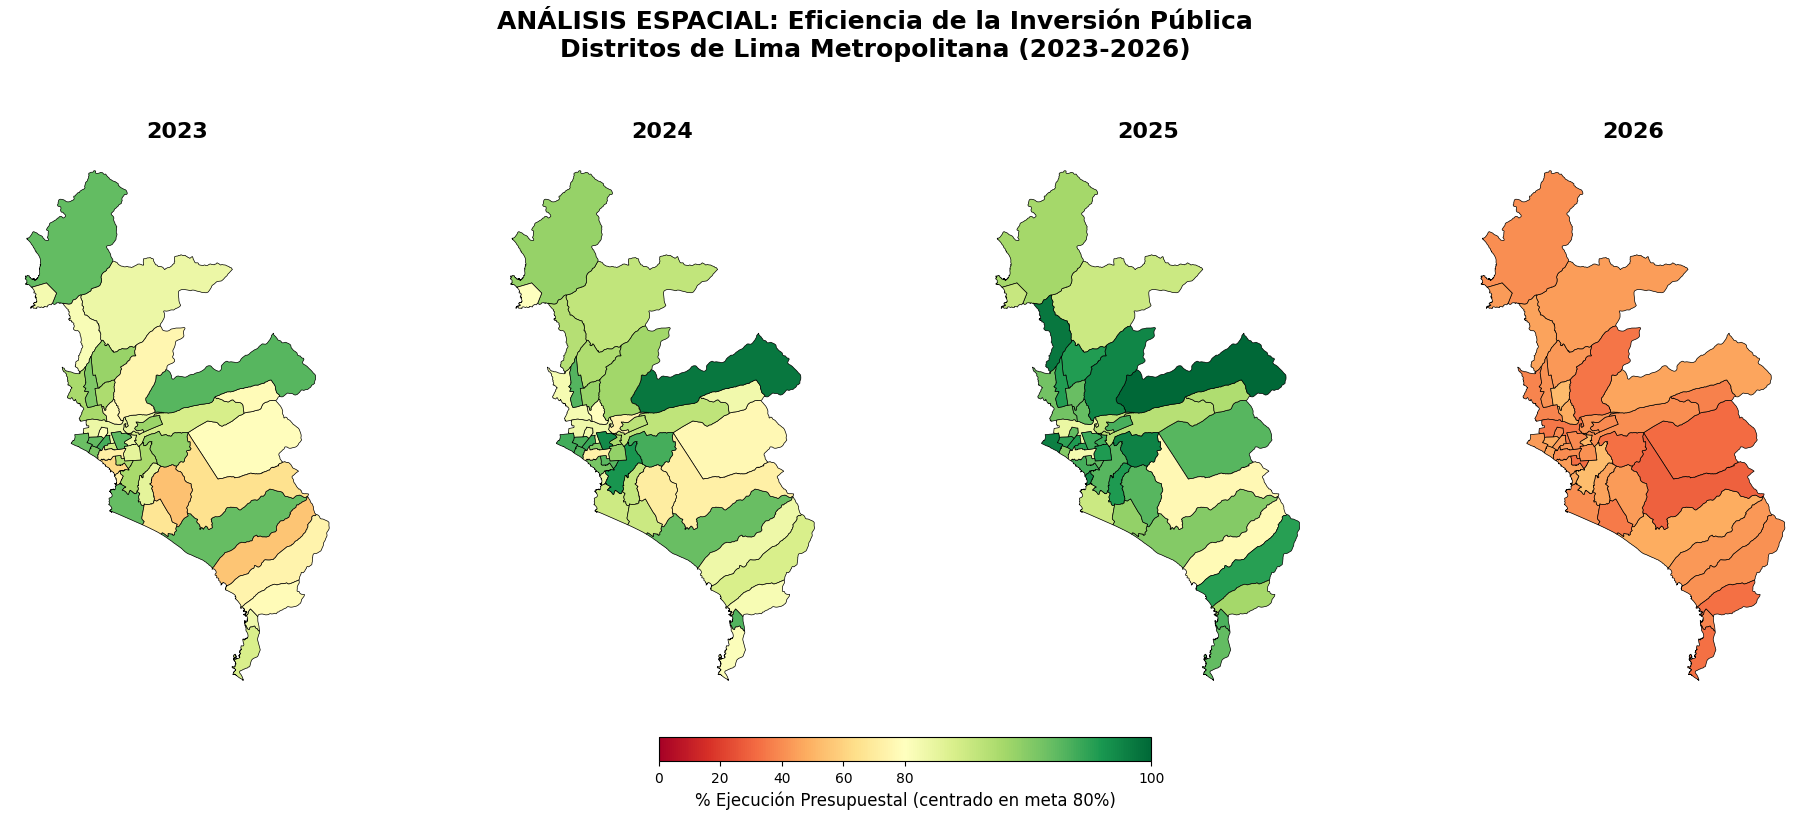

In [ ]:
# CELDA 23: Fig03 — Mapa coroplético de Lima Metropolitana, 4 años
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Escala de color centrada en la meta de 80%
norm_centrado = mcolors.TwoSlopeNorm(vmin=0, vcenter=80, vmax=100)

fig, axes = plt.subplots(1, 4, figsize=(24, 8))

años = [2023, 2024, 2025, 2026]

for ax, año in zip(axes, años):
    datos_año = gdf_lima_datos[gdf_lima_datos['año'] == año]

    datos_año.plot(
        column='pct_ejecucion',
        cmap='RdYlGn',
        linewidth=0.5,
        edgecolor='black',
        ax=ax,
        legend=False,
        norm=norm_centrado
    )

    ax.set_title(f'{año}', fontsize=16, fontweight='bold')
    ax.axis('off')

# Barra de color compartida
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=norm_centrado)
sm._A = []
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.04, pad=0.05)
cbar.set_label('% Ejecución Presupuestal (centrado en meta 80%)', fontsize=12)

fig.suptitle('ANÁLISIS ESPACIAL: Eficiencia de la Inversión Pública\nDistritos de Lima Metropolitana (2023-2026)',
             fontsize=18, fontweight='bold', y=1.05)

ruta_out = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /05_Reportes   /'
plt.savefig(ruta_out + 'Fig03_Mapa_Eficiencia_Distrital.png', dpi=200, bbox_inches='tight')
print("✅ Fig03 guardada — Mapa de los 4 años (escala centrada en meta 80%)")
plt.show()

In [ ]:
# CELDA 25: Función reutilizable para gráfico de ranking por año
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def graficar_ranking(año, nombre_archivo, nota_pie=None):
    df_año = (df_lima_metro_limpio[df_lima_metro_limpio['año']==año]
              .sort_values('pct_ejecucion', ascending=True)
              .copy())

    def color_por_pct(pct):
        if pct >= 80:
            return '#27ae60'
        elif pct >= 60:
            return '#e67e22'
        else:
            return '#c0392b'

    colores = df_año['pct_ejecucion'].apply(color_por_pct)

    fig, ax = plt.subplots(figsize=(12, 16))
    ax.barh(df_año['distrito_limpio'], df_año['pct_ejecucion'],
            color=colores, height=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(x=80, color='navy', linestyle='--', linewidth=1.5)

    for i, val in enumerate(df_año['pct_ejecucion']):
        ax.text(val + 1, i, f'{val}%', va='center', fontsize=9, fontweight='bold')

    ax.set_xlabel('% Ejecución Presupuestal', fontsize=12)
    titulo = f'EFICIENCIA PRESUPUESTAL\nDistritos de Lima Metropolitana {año}\n(ordenado de mayor a menor)'
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 110)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    leyenda = [
        mpatches.Patch(color='#27ae60', label='≥ 80% Eficiente'),
        mpatches.Patch(color='#e67e22', label='60-79% Regular'),
        mpatches.Patch(color='#c0392b', label='< 60% Crítico')
    ]
    ax.legend(handles=leyenda, loc='lower right', fontsize=10)

    if nota_pie:
        fig.text(0.5, -0.01, nota_pie, ha='center', fontsize=9, style='italic', color='gray')

    plt.tight_layout()
    ruta_out = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /05_Reportes   /'
    plt.savefig(ruta_out + nombre_archivo, dpi=200, bbox_inches='tight')
    print(f"✅ Guardado: {nombre_archivo}")
    plt.show()

print("Función lista ✅")

Función lista ✅


✅ Guardado: Fig04_Ranking_2024.png


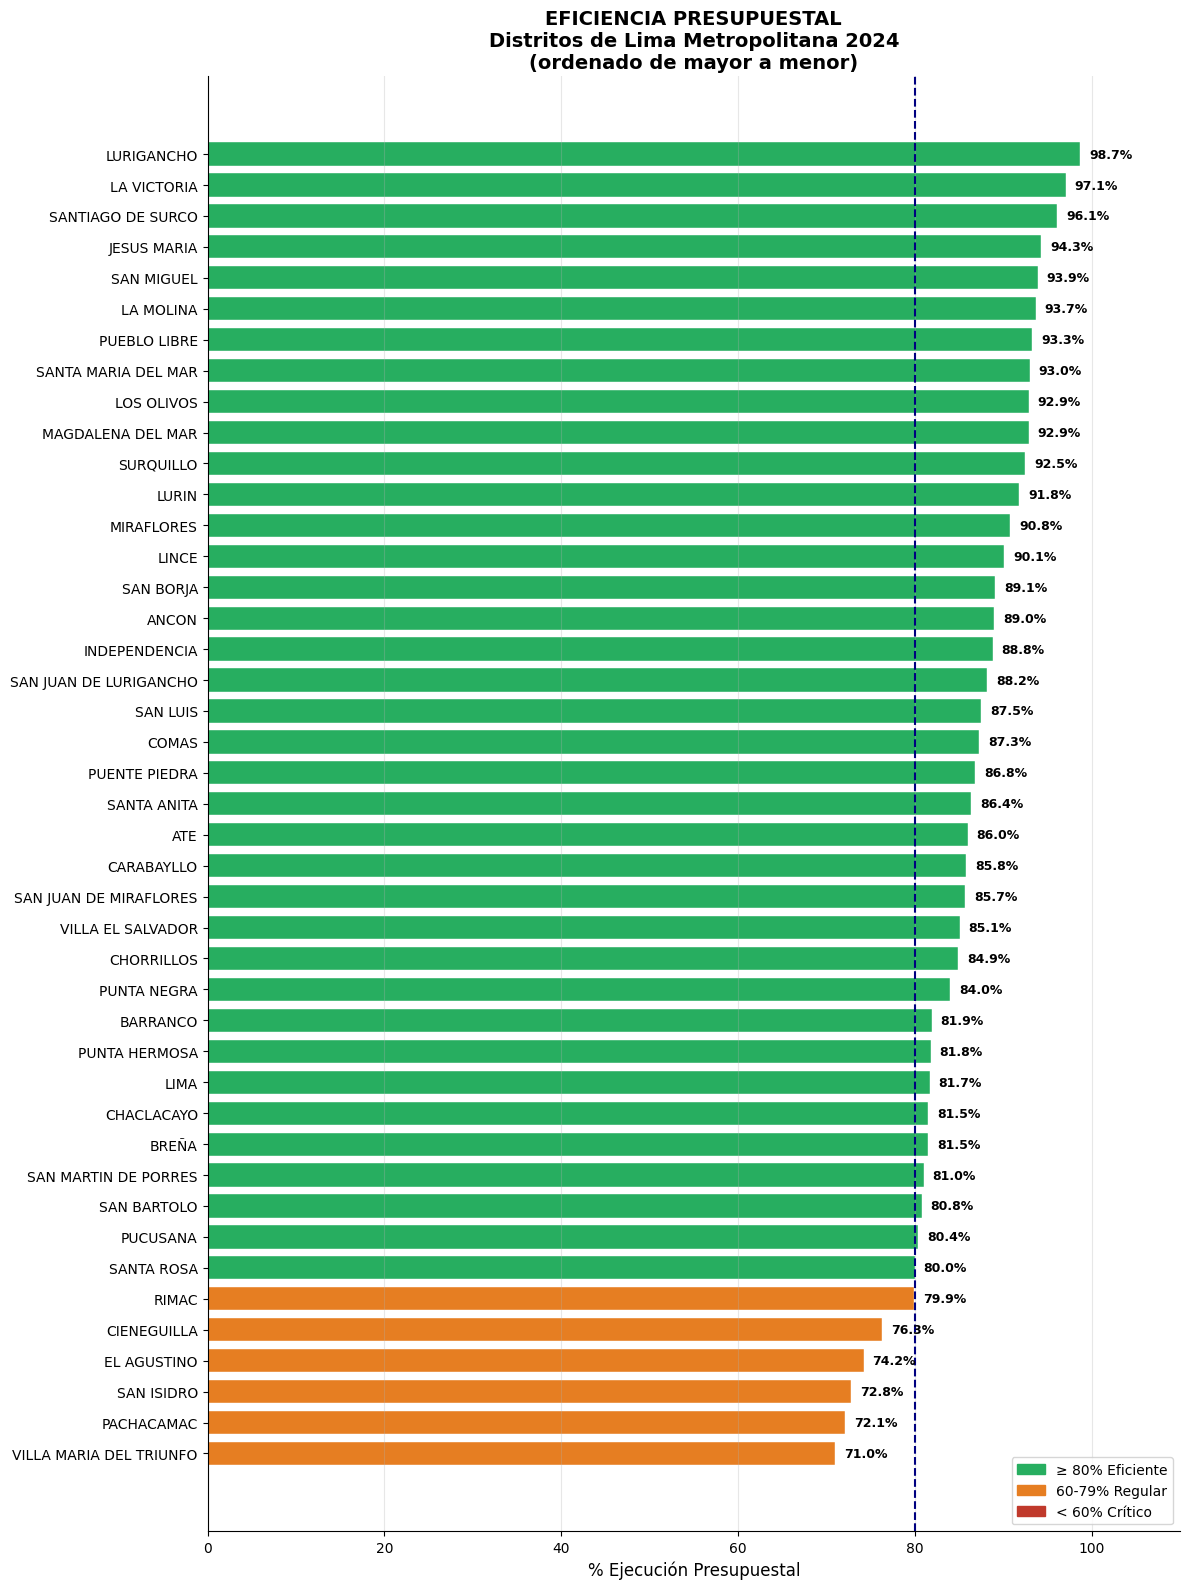

In [ ]:
graficar_ranking(2024, 'Fig04_Ranking_2024.png')

✅ Guardado: Fig05_Ranking_2025.png


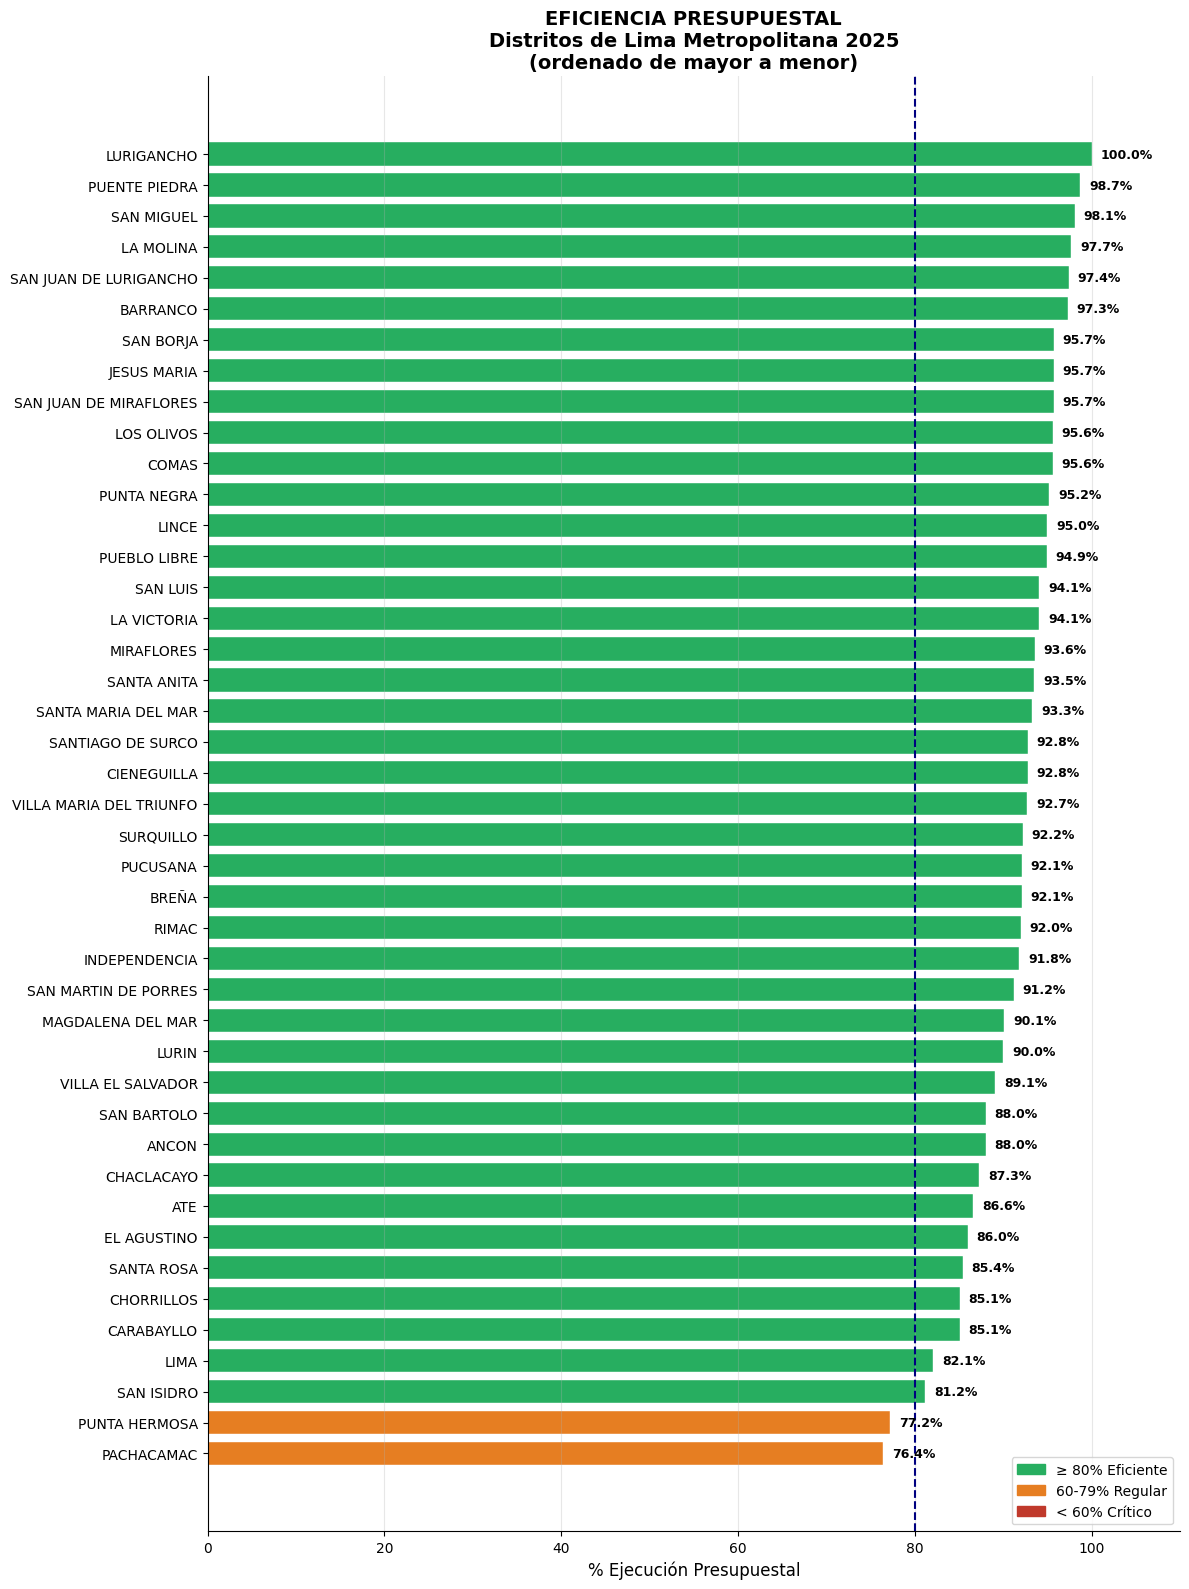

In [ ]:
graficar_ranking(2025, 'Fig05_Ranking_2025.png')

✅ Guardado: Fig06_Ranking_2026.png


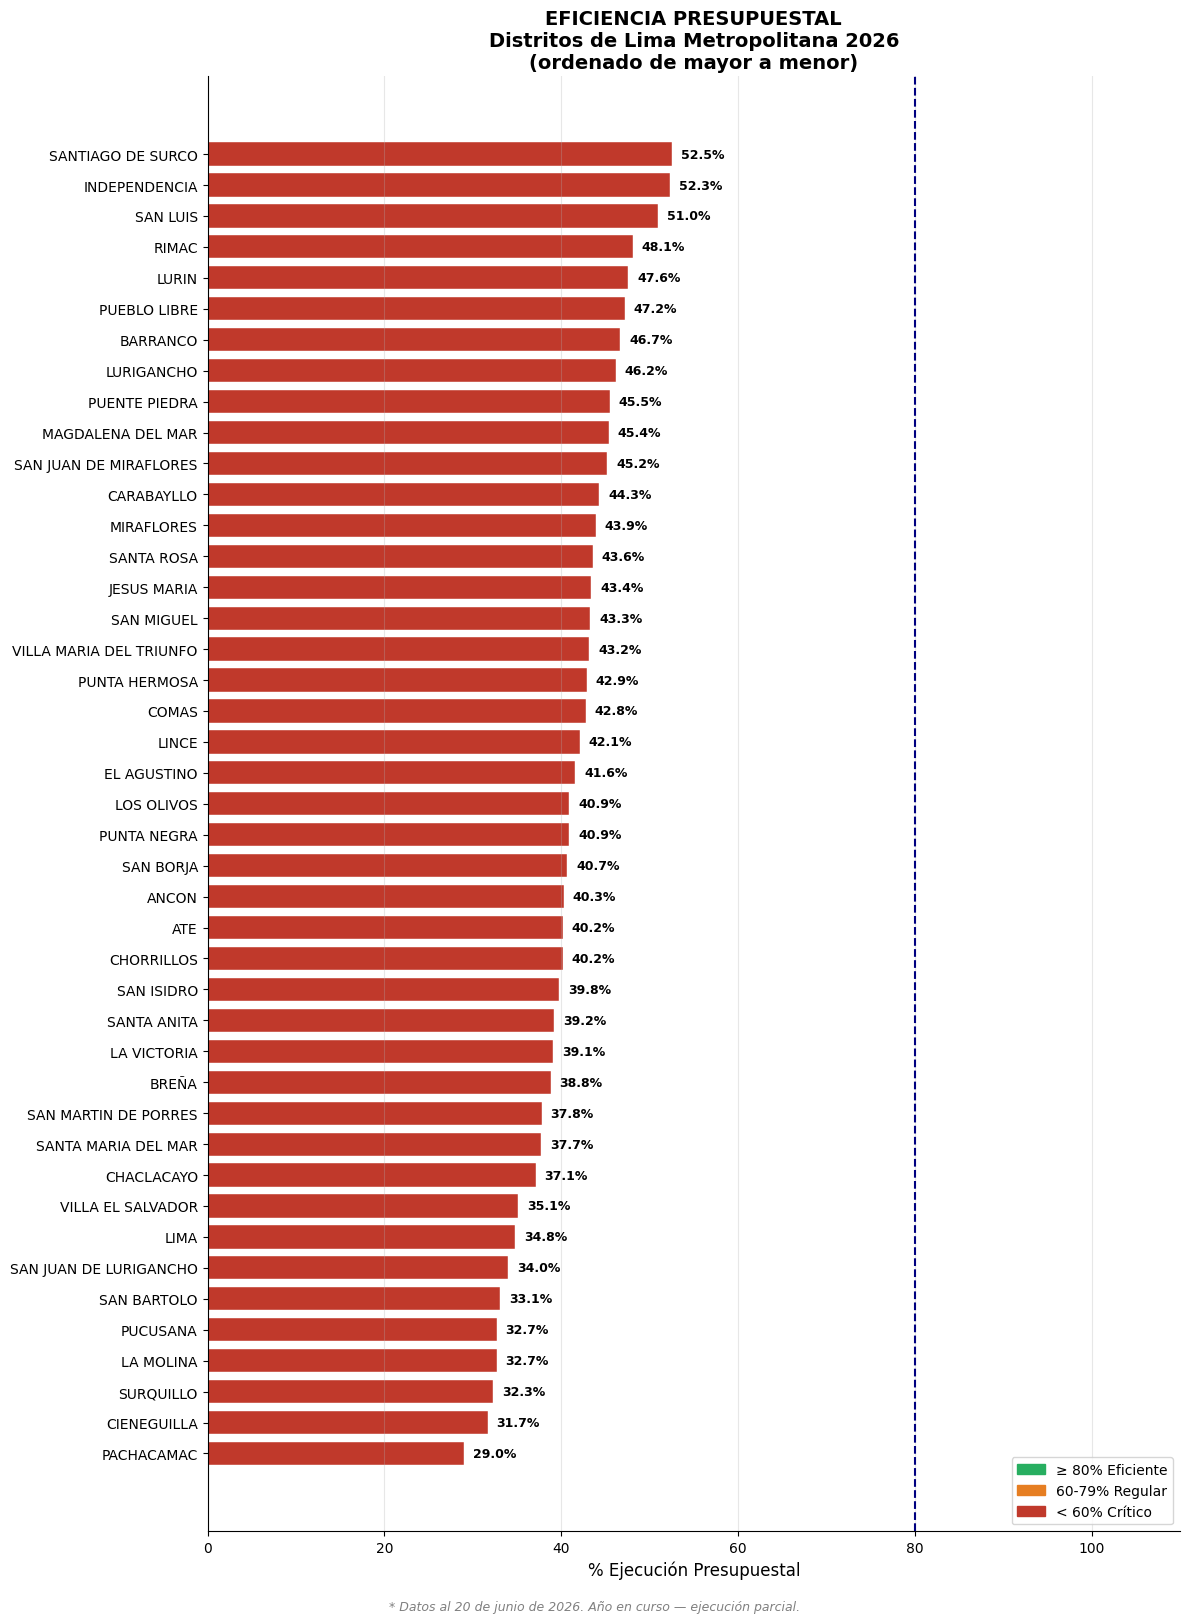

In [ ]:
# CELDA 26: Fig06 — Ranking 2026 (año en curso)
graficar_ranking(
    2026,
    'Fig06_Ranking_2026.png',
    nota_pie='* Datos al 20 de junio de 2026. Año en curso — ejecución parcial.'
)

/tmp/ipykernel_3469/1642127548.py:88: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3469/1642127548.py:91: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig(ruta_out + 'Fig07_Top5_Bottom5_Evolucion.png', dpi=200, bbox_inches='tight')


✅ Fig07 mejorado guardado


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


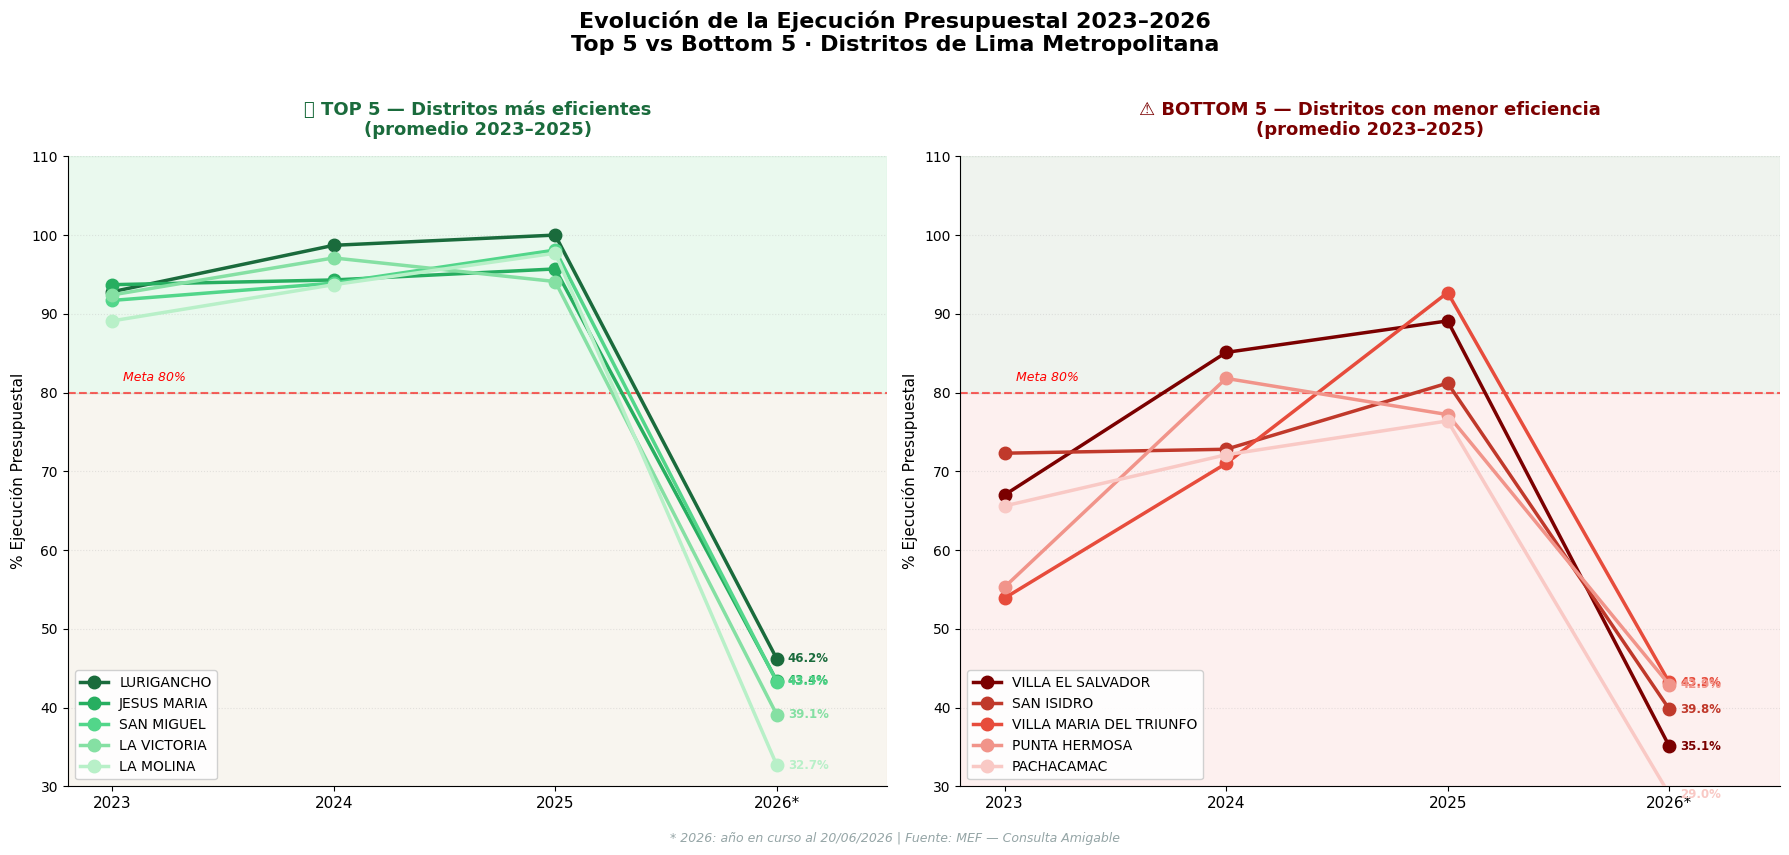

In [ ]:
# CELDA 27 : Fig07 — Top 5 y Bottom 5
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ranking_promedio = (df_lima_metro_limpio[df_lima_metro_limpio['año'] <= 2025]
                    .groupby('distrito_limpio')['pct_ejecucion']
                    .mean()
                    .sort_values(ascending=False))

top5 = ranking_promedio.head(5).index.tolist()
bottom5 = ranking_promedio.tail(5).index.tolist()

años = [2023, 2024, 2025, 2026]

colores_top = ['#1a6b3c','#27ae60','#52d68a','#85e0a3','#b8f0c8']
colores_bot = ['#7b0000','#c0392b','#e74c3c','#f1948a','#f9c9c5']

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('white')

# ── TOP 5 ──
ax = axes[0]
ax.set_facecolor('#f9fff9')
ax.axhspan(80, 110, alpha=0.07, color='#27ae60')
ax.axhspan(0, 80, alpha=0.05, color='#e74c3c')
ax.axhline(y=80, color='red', linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
ax.text(2023.05, 81.5, 'Meta 80%', color='red', fontsize=9, style='italic')

for i, distrito in enumerate(top5):
    datos = df_lima_metro_limpio[df_lima_metro_limpio['distrito_limpio']==distrito].sort_values('año')
    ax.plot(datos['año'], datos['pct_ejecucion'],
            marker='o', linewidth=2.5, markersize=9,
            color=colores_top[i], label=distrito, zorder=3)
    # Etiqueta al final de la línea
    ultimo = datos[datos['año']==2026]
    ax.text(2026.05, ultimo['pct_ejecucion'].values[0],
            f"{ultimo['pct_ejecucion'].values[0]}%",
            fontsize=8.5, color=colores_top[i], fontweight='bold', va='center')

ax.set_title('🏆 TOP 5 — Distritos más eficientes\n(promedio 2023–2025)',
             fontsize=13, fontweight='bold', color='#1a6b3c', pad=15)
ax.set_ylim(30, 110)
ax.set_xlim(2022.8, 2026.5)
ax.set_xticks(años)
ax.set_xticklabels(['2023', '2024', '2025', '2026*'], fontsize=11)
ax.set_ylabel('% Ejecución Presupuestal', fontsize=11)
ax.legend(fontsize=10, loc='lower left', framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── BOTTOM 5 ──
ax = axes[1]
ax.set_facecolor('#fff9f9')
ax.axhspan(80, 110, alpha=0.07, color='#27ae60')
ax.axhspan(0, 80, alpha=0.05, color='#e74c3c')
ax.axhline(y=80, color='red', linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
ax.text(2023.05, 81.5, 'Meta 80%', color='red', fontsize=9, style='italic')

for i, distrito in enumerate(bottom5):
    datos = df_lima_metro_limpio[df_lima_metro_limpio['distrito_limpio']==distrito].sort_values('año')
    ax.plot(datos['año'], datos['pct_ejecucion'],
            marker='o', linewidth=2.5, markersize=9,
            color=colores_bot[i], label=distrito, zorder=3)
    ultimo = datos[datos['año']==2026]
    ax.text(2026.05, ultimo['pct_ejecucion'].values[0],
            f"{ultimo['pct_ejecucion'].values[0]}%",
            fontsize=8.5, color=colores_bot[i], fontweight='bold', va='center')

ax.set_title('⚠️ BOTTOM 5 — Distritos con menor eficiencia\n(promedio 2023–2025)',
             fontsize=13, fontweight='bold', color='#7b0000', pad=15)
ax.set_ylim(30, 110)
ax.set_xlim(2022.8, 2026.5)
ax.set_xticks(años)
ax.set_xticklabels(['2023', '2024', '2025', '2026*'], fontsize=11)
ax.set_ylabel('% Ejecución Presupuestal', fontsize=11)
ax.legend(fontsize=10, loc='lower left', framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Evolución de la Ejecución Presupuestal 2023–2026\nTop 5 vs Bottom 5 · Distritos de Lima Metropolitana',
             fontsize=16, fontweight='bold', y=1.02)

fig.text(0.5, -0.02, '* 2026: año en curso al 20/06/2026 | Fuente: MEF — Consulta Amigable',
         ha='center', fontsize=9, color='#95a5a6', style='italic')

plt.tight_layout()

ruta_out = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /05_Reportes   /'
plt.savefig(ruta_out + 'Fig07_Top5_Bottom5_Evolucion.png', dpi=200, bbox_inches='tight')
print("✅ Fig07 mejorado guardado")
plt.show()

/tmp/ipykernel_3469/622083874.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_boxplot,


✅ Fig08 guardada


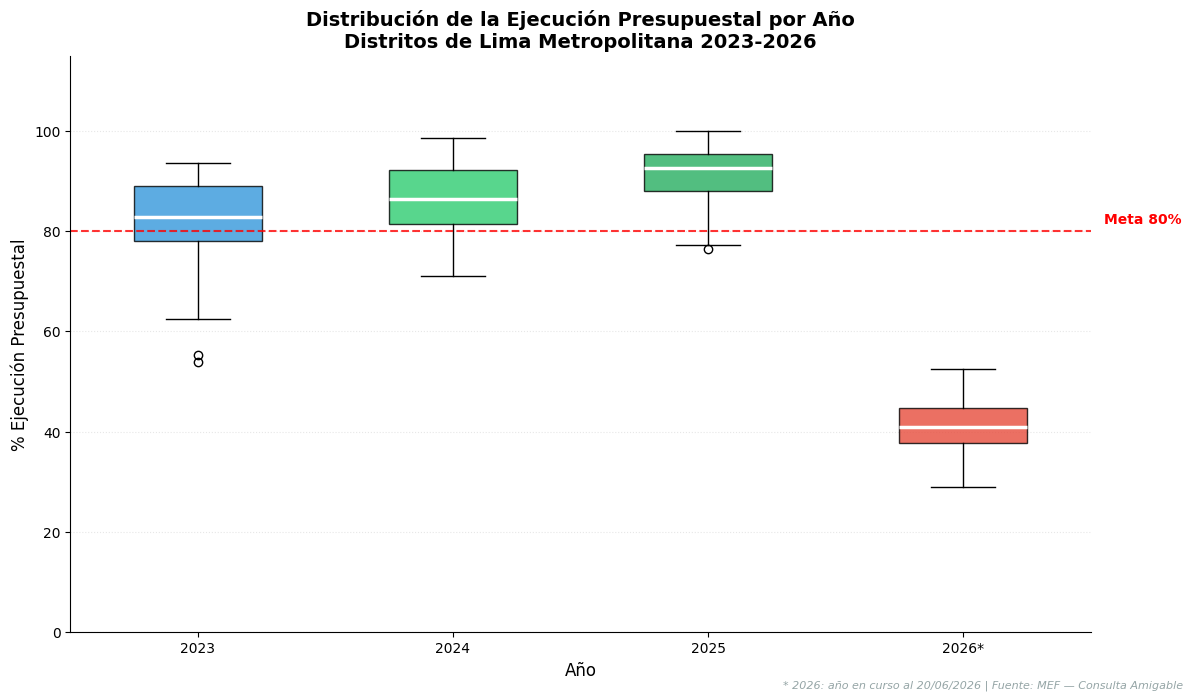

In [ ]:
# CELDA 28: Fig08 — Boxplot comparativo 4 años
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

datos_boxplot = [
    df_lima_metro_limpio[df_lima_metro_limpio['año']==año]['pct_ejecucion'].dropna().values
    for año in [2023, 2024, 2025, 2026]
]

colores_box = ['#3498db', '#2ecc71', '#27ae60', '#e74c3c']

bp = ax.boxplot(datos_boxplot,
                patch_artist=True,
                labels=['2023', '2024', '2025', '2026*'],
                widths=0.5,
                medianprops=dict(color='white', linewidth=2.5))

for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.axhline(y=80, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(4.55, 81.5, 'Meta 80%', color='red', fontsize=10, fontweight='bold')

ax.set_ylabel('% Ejecución Presupuestal', fontsize=12)
ax.set_xlabel('Año', fontsize=12)
ax.set_title('Distribución de la Ejecución Presupuestal por Año\nDistritos de Lima Metropolitana 2023-2026',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.99, 0.01, '* 2026: año en curso al 20/06/2026 | Fuente: MEF — Consulta Amigable',
         ha='right', fontsize=8, color='#95a5a6', style='italic')

plt.tight_layout()

ruta_out = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /05_Reportes   /'
plt.savefig(ruta_out + 'Fig08_Boxplot_Distribucion.png', dpi=200, bbox_inches='tight')
print("✅ Fig08 guardada")
plt.show()

In [ ]:
# CELDA 29: Tabla resumen estadísticas por año
tabla_stats = df_lima_metro_limpio.groupby('año')['pct_ejecucion'].agg([
    ('Promedio', 'mean'),
    ('Mediana', 'median'),
    ('Mínimo', 'min'),
    ('Máximo', 'max'),
    ('Desv. Estándar', 'std')
]).round(1)

print("📊 ESTADÍSTICAS POR AÑO")
print(tabla_stats)

📊 ESTADÍSTICAS POR AÑO
      Promedio  Mediana  Mínimo  Máximo  Desv. Estándar
año                                                    
2023      81.8     82.8    53.9    93.7             9.8
2024      86.1     86.4    71.0    98.7             6.9
2025      91.4     92.7    76.4   100.0             5.5
2026      41.1     40.9    29.0    52.5             5.6


✅ Fig09 mejorado guardado


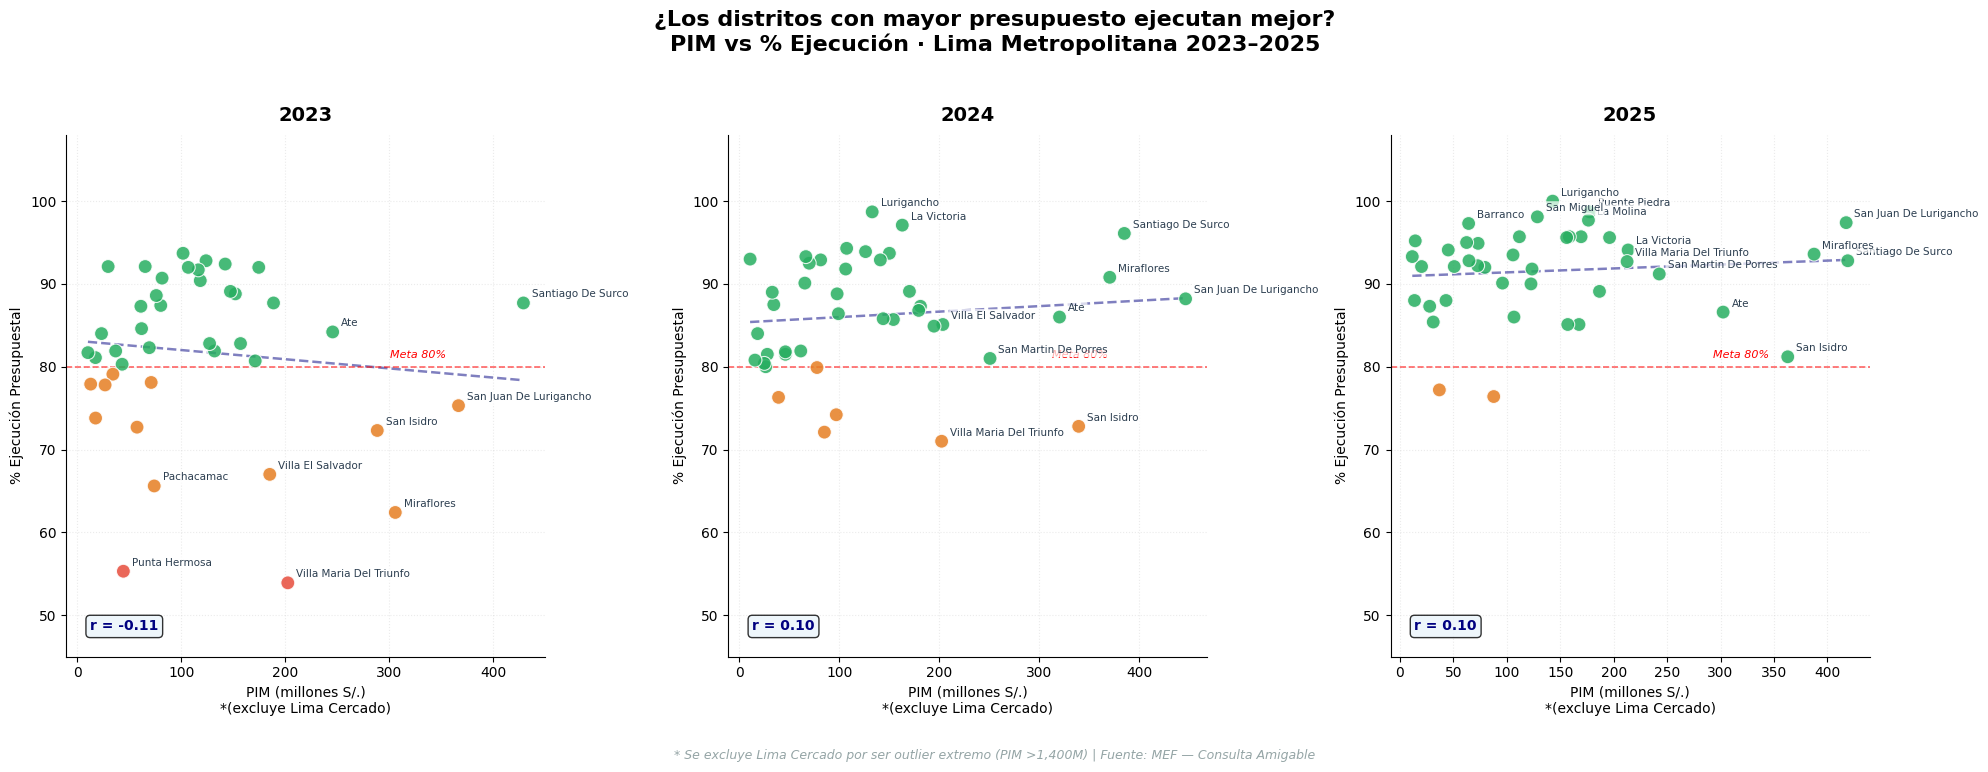

In [ ]:
# CELDA 30 MEJORADO: Fig09 — Scatter PIM vs Ejecución (versión profesional)
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('white')

años = [2023, 2024, 2025]

for ax, año in zip(axes, años):
    datos = df_lima_metro_limpio[df_lima_metro_limpio['año']==año].copy()
    # Excluir Lima Metropolitana (outlier extremo)
    datos = datos[datos['distrito_limpio'] != 'LIMA'].copy()
    datos['PIM_millones'] = datos['PIM'] / 1_000_000

    colores = datos['pct_ejecucion'].apply(
        lambda x: '#27ae60' if x >= 80 else '#e67e22' if x >= 60 else '#e74c3c'
    )

    ax.scatter(datos['PIM_millones'], datos['pct_ejecucion'],
               c=colores, s=100, alpha=0.85,
               edgecolors='white', linewidth=0.8, zorder=3)

    # Línea de tendencia
    z = np.polyfit(datos['PIM_millones'], datos['pct_ejecucion'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(datos['PIM_millones'].min(), datos['PIM_millones'].max(), 100)
    ax.plot(x_line, p(x_line), color='navy', linewidth=1.8,
            linestyle='--', alpha=0.5, label='Tendencia')

    # Meta 80%
    ax.axhline(y=80, color='red', linestyle='--', linewidth=1.2, alpha=0.6)
    ax.text(datos['PIM_millones'].max()*0.7, 81,
            'Meta 80%', color='red', fontsize=8, style='italic')

    # Etiquetar solo los más relevantes
    destacados = datos[
        (datos['pct_ejecucion'] < 70) |
        (datos['PIM_millones'] > 200) |
        (datos['pct_ejecucion'] > 97)
    ]
    for _, row in destacados.iterrows():
        ax.annotate(row['distrito_limpio'].title(),
                   xy=(row['PIM_millones'], row['pct_ejecucion']),
                   xytext=(6, 4), textcoords='offset points',
                   fontsize=7.5, color='#2c3e50', fontweight='500',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                            alpha=0.7, edgecolor='none'))

    # Correlación
    corr = datos['PIM_millones'].corr(datos['pct_ejecucion'])
    ax.text(0.05, 0.05, f'r = {corr:.2f}',
            transform=ax.transAxes, fontsize=10,
            color='navy', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#eaf4fb', alpha=0.8))

    ax.set_title(f'{año}', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('PIM (millones S/.)\n*(excluye Lima Cercado)', fontsize=10)
    ax.set_ylabel('% Ejecución Presupuestal', fontsize=10)
    ax.set_ylim(45, 108)
    ax.grid(alpha=0.25, linestyle=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor('white')

fig.suptitle('¿Los distritos con mayor presupuesto ejecutan mejor?\nPIM vs % Ejecución · Lima Metropolitana 2023–2025',
             fontsize=16, fontweight='bold', y=1.03)

fig.text(0.5, -0.04,
         '* Se excluye Lima Cercado por ser outlier extremo (PIM >1,400M) | Fuente: MEF — Consulta Amigable',
         ha='center', fontsize=9, color='#95a5a6', style='italic')

plt.tight_layout()

ruta_out = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /05_Reportes   /'
plt.savefig(ruta_out + 'Fig09_Scatter_PIM_vs_Ejecucion.png',
            dpi=200, bbox_inches='tight', facecolor='white')
print("✅ Fig09 mejorado guardado")
plt.show()

In [ ]:
# CELDA 31: Tabla de clasificación final de distritos
datos_3años = df_lima_metro_limpio[df_lima_metro_limpio['año'] <= 2025]

clasificacion = datos_3años.groupby('distrito_limpio')['pct_ejecucion'].agg(
    promedio='mean',
    sobre_80=lambda x: (x >= 80).sum()
).round(1)

def clasificar(row):
    if row['sobre_80'] == 3:
        return '🟢 Eficiente Consistente'
    elif row['sobre_80'] == 2:
        return '🟡 En Mejora'
    elif row['sobre_80'] == 1:
        return '🟠 Irregular'
    else:
        return '🔴 Crítico Persistente'

clasificacion['categoria'] = clasificacion.apply(clasificar, axis=1)
clasificacion = clasificacion.sort_values('promedio', ascending=False)

print("CLASIFICACIÓN FINAL DE DISTRITOS (2023-2025)")
print("="*60)
for cat in ['🟢 Eficiente Consistente','🟡 En Mejora','🟠 Irregular','🔴 Crítico Persistente']:
    grupo = clasificacion[clasificacion['categoria']==cat]
    print(f"\n{cat} ({len(grupo)} distritos):")
    for dist, row in grupo.iterrows():
        print(f"  {dist.title():<30} promedio: {row['promedio']}%")

ruta_out = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /02_Datos_Limpios /'
clasificacion.to_csv(ruta_out + 'clasificacion_distritos.csv')
print("\n✅ Tabla guardada")

CLASIFICACIÓN FINAL DE DISTRITOS (2023-2025)

🟢 Eficiente Consistente (29 distritos):
  Lurigancho                     promedio: 97.2%
  Jesus Maria                    promedio: 94.6%
  San Miguel                     promedio: 94.6%
  La Victoria                    promedio: 94.5%
  La Molina                      promedio: 93.5%
  Pueblo Libre                   promedio: 93.4%
  Los Olivos                     promedio: 93.0%
  Santiago De Surco              promedio: 92.2%
  Lurin                          promedio: 91.3%
  Magdalena Del Mar              promedio: 91.2%
  Surquillo                      promedio: 90.7%
  Comas                          promedio: 90.6%
  Lince                          promedio: 89.9%
  Ancon                          promedio: 89.7%
  Santa Anita                    promedio: 89.5%
  Independencia                  promedio: 89.3%
  Santa Maria Del Mar            promedio: 89.3%
  San Borja                      promedio: 89.2%
  Puente Piedra                 

✅ Fig10 guardada


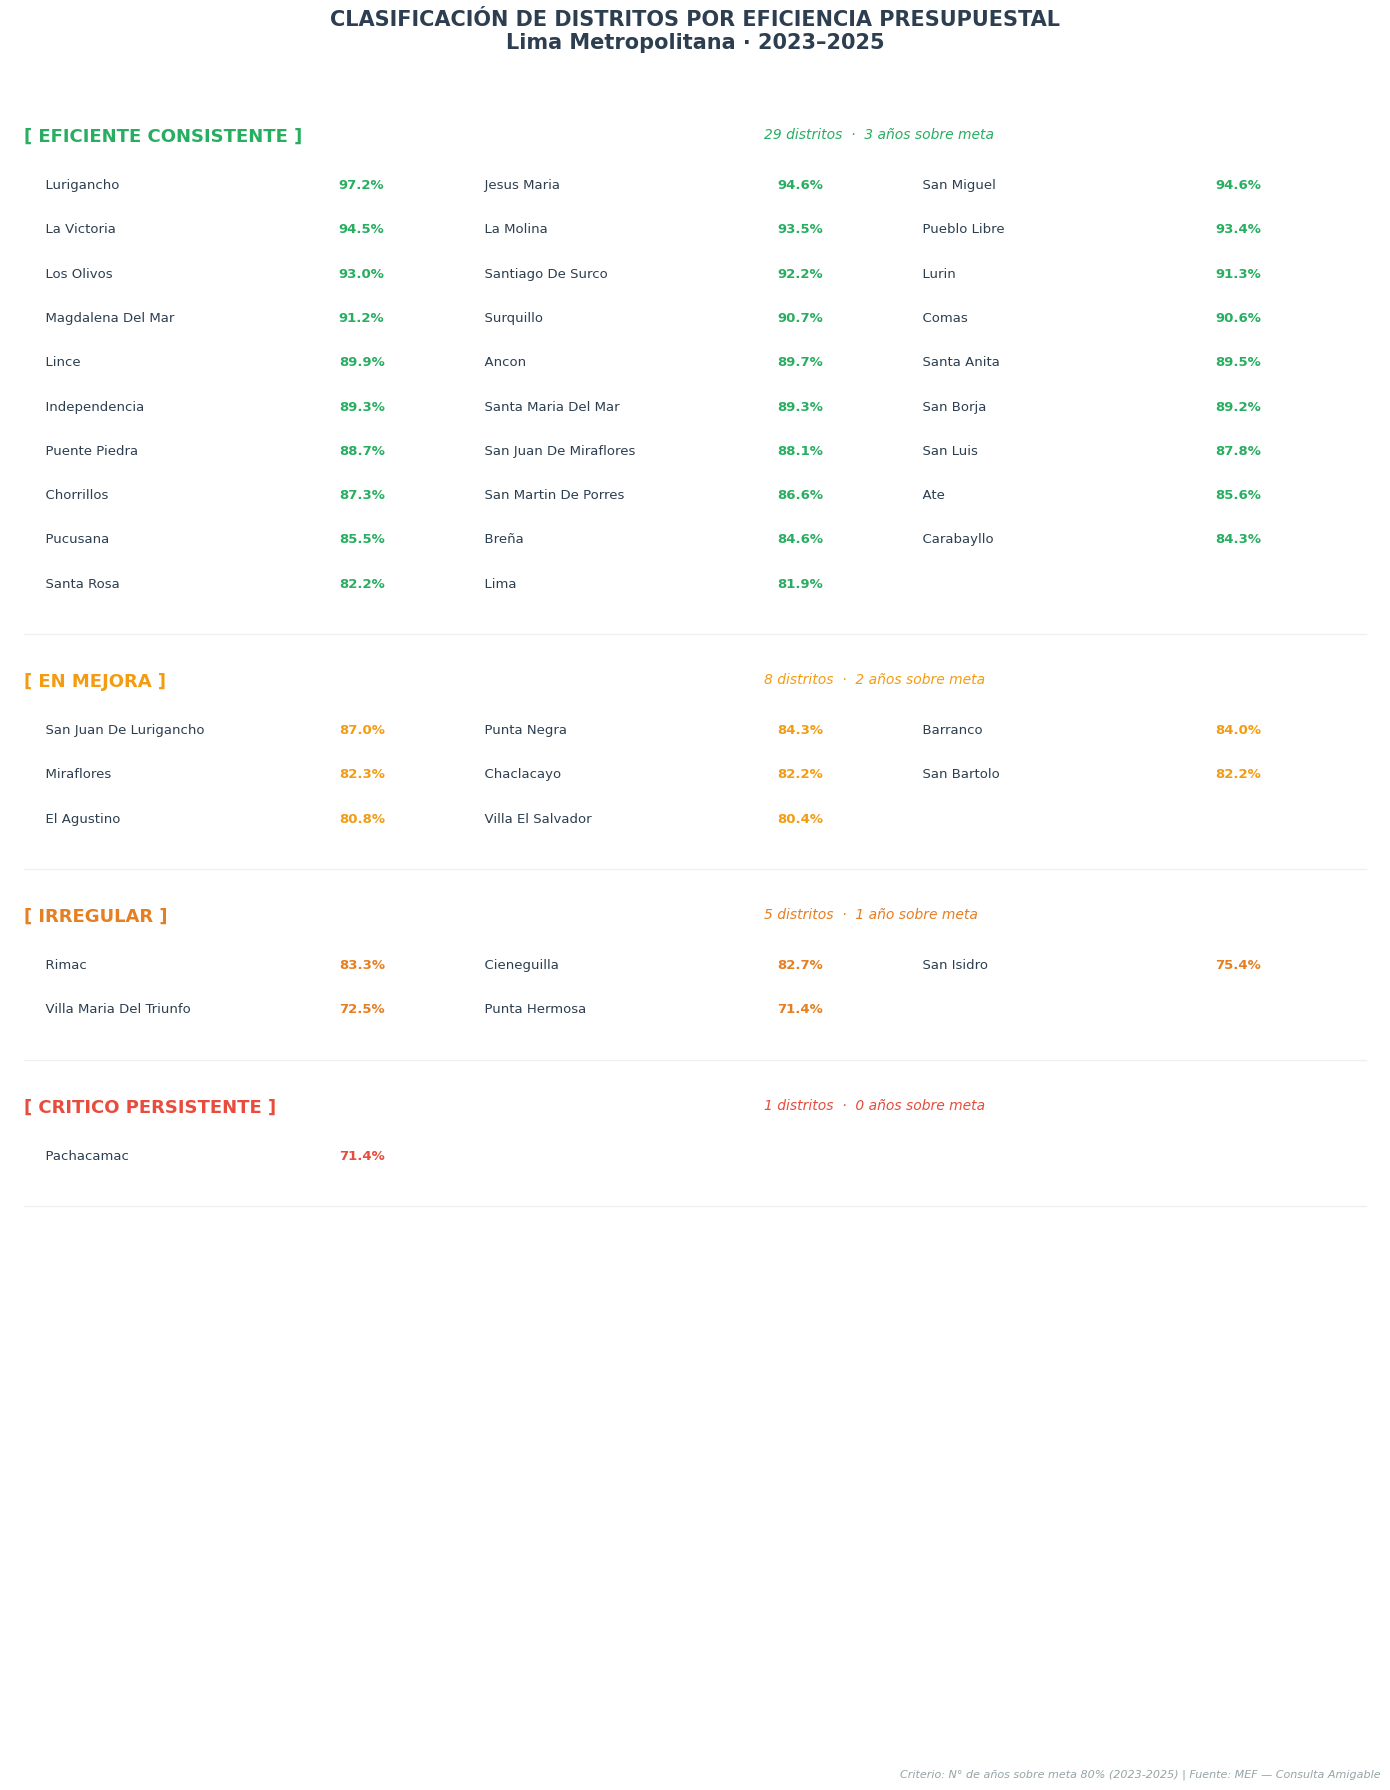

In [ ]:
# CELDA 32: Fig10 — Tabla visual de clasificación
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 18))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')

categorias = {
    'EFICIENTE CONSISTENTE': ('#27ae60', '3 años sobre meta'),
    'EN MEJORA':             ('#f39c12', '2 años sobre meta'),
    'IRREGULAR':             ('#e67e22', '1 año sobre meta'),
    'CRITICO PERSISTENTE':   ('#e74c3c', '0 años sobre meta'),
}

cat_map = {
    'EFICIENTE CONSISTENTE': '🟢 Eficiente Consistente',
    'EN MEJORA':             '🟡 En Mejora',
    'IRREGULAR':             '🟠 Irregular',
    'CRITICO PERSISTENTE':   '🔴 Crítico Persistente',
}

y = 0.97
for cat_key, (color_texto, criterio) in categorias.items():
    cat_real = cat_map[cat_key]
    grupo = clasificacion[clasificacion['categoria']==cat_real].reset_index()

    # Header
    ax.text(0.01, y, f'[ {cat_key} ]',
            fontsize=13, fontweight='bold',
            color=color_texto, transform=ax.transAxes, va='top')
    ax.text(0.55, y, f'{len(grupo)} distritos  ·  {criterio}',
            fontsize=10, color=color_texto,
            transform=ax.transAxes, va='top', style='italic')
    y -= 0.03

    # Distritos en 3 columnas
    cols = 3
    for i, row in grupo.iterrows():
        col = i % cols
        fila = i // cols
        x_pos = 0.02 + col * 0.32
        y_pos = y - fila * 0.026

        ax.text(x_pos, y_pos,
                f"  {row['distrito_limpio'].title()}",
                fontsize=9.5, color='#2c3e50',
                transform=ax.transAxes, va='top')
        ax.text(x_pos + 0.22, y_pos,
                f"{row['promedio']}%",
                fontsize=9.5, color=color_texto,
                fontweight='bold', transform=ax.transAxes, va='top')

    filas_usadas = (len(grupo) - 1) // cols + 1
    y -= filas_usadas * 0.026 + 0.015

    # Línea separadora simple
    ax.plot([0.01, 0.99], [y + 0.008, y + 0.008],
            color='#ecf0f1', linewidth=1,
            transform=ax.transAxes)
    y -= 0.015

ax.set_title('CLASIFICACIÓN DE DISTRITOS POR EFICIENCIA PRESUPUESTAL\nLima Metropolitana · 2023–2025',
             fontsize=15, fontweight='bold', pad=20, color='#2c3e50')

fig.text(0.99, 0.01,
         'Criterio: N° de años sobre meta 80% (2023-2025) | Fuente: MEF — Consulta Amigable',
         ha='right', fontsize=8, color='#95a5a6', style='italic')

plt.tight_layout()

ruta_out = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /05_Reportes   /'
plt.savefig(ruta_out + 'Fig10_Clasificacion_Distritos.png',
            dpi=200, bbox_inches='tight', facecolor='white')
print("✅ Fig10 guardada")
plt.show()

In [ ]:
# CELDA NUEVA: Crear columna de Brecha de Inversión
df_lima_metro_limpio['brecha_inversion'] = df_lima_metro_limpio['PIM'] - df_lima_metro_limpio['Devengado']

print("Columna creada ✅")
print(df_lima_metro_limpio[['distrito_limpio','año','PIM','Devengado','pct_ejecucion','brecha_inversion']].head(10))

Columna creada ✅
            distrito_limpio   año         PIM   Devengado  pct_ejecucion  \
342                    LIMA  2025  3206134713  2633767350           82.1   
171                    LIMA  2024  2814948717  2298876016           81.7   
513                    LIMA  2026  2728260767   950765556           34.8   
161                    LIMA  2023  1443207124  1182961106           82.0   
202  SAN JUAN DE LURIGANCHO  2024   446618478   393801322           88.2   
544  SAN JUAN DE LURIGANCHO  2026   440102016   149430802           34.0   
141       SANTIAGO DE SURCO  2023   428857206   376057479           87.7   
381       SANTIAGO DE SURCO  2025   418991999   388814949           92.8   
373  SAN JUAN DE LURIGANCHO  2025   417491363   406494073           97.4   
552       SANTIAGO DE SURCO  2026   402792452   211522601           52.5   

     brecha_inversion  
342         572367363  
171         516072701  
513        1777495211  
161         260246018  
202          52817156  
54

In [ ]:
# CELDA NUEVA: Guardar tabla final con Brecha de Inversión incluida
ruta_out = '/content/drive/MyDrive/Proyecto_MuniMetro_Lima /02_Datos_Limpios /'
df_lima_metro_limpio.to_csv(ruta_out + 'lima_metropolitana_final.csv', index=False)
print("✅ Guardado: lima_metropolitana_final.csv")
print("Filas:", len(df_lima_metro_limpio), "| Columnas:", df_lima_metro_limpio.shape[1])
print("\nColumnas incluidas:")
print(df_lima_metro_limpio.columns.tolist())

✅ Guardado: lima_metropolitana_final.csv
Filas: 172 | Columnas: 13

Columnas incluidas:
['Municipalidad', 'PIA', 'PIM', 'Certificacion', 'Compromiso_Anual', 'Atencion_Compromiso', 'Devengado', 'Girado', 'Avance', 'año', 'pct_ejecucion', 'distrito_limpio', 'brecha_inversion']
